# Entregável 6 — Extração de Atributos do ECG (Feature Extraction)

**Disciplina:** Aquisição e Processamento de Biossinais  
**Equipe:** José Ferreira Lessa & Matheus Rocha Gomes da Silva  
**Orientador:** Prof. Dr. Victor Hugo C. de Albuquerque  
**Dataset:** PTB-XL — A Large Publicly Available Electrocardiography Dataset (PhysioNet)  
**Referência:** Wagner et al. (2020). PTB-XL, a large publicly available electrocardiography dataset. *Scientific Data*, 7(1), 154.  
**Data:** Abril e Maio de 2026

---

## Objetivo

Este notebook descreve a etapa de **Extração de Atributos (Feature Extraction)**, responsável por transformar os sinais de ECG — previamente limpos (Entregável 4) e segmentados (Entregável 5) — em um conjunto estruturado de variáveis numéricas que representem, de forma compacta e informativa, a atividade elétrica cardíaca.

Do ponto de vista metodológico, esta etapa conecta o processamento de sinais à modelagem, convertendo dados contínuos em descritores quantitativos utilizáveis por algoritmos de aprendizado de máquina. Embora abordagens modernas permitam o uso direto do sinal bruto, a engenharia de atributos permanece essencial em cenários que exigem interpretabilidade clínica e maior controle analítico.

A estratégia adotada neste trabalho é **hierárquica e híbrida**, em dois níveis:

1. **Nível Global (registro de 10 s):** extração de estatísticas, energia e conteúdo espectral nas 12 derivações.
2. **Nível Local (batimento):** extração de características morfológicas e métricas de variabilidade de ritmo (HRV), posteriormente agregadas ao nível do registro, mantendo a consistência da instância principal.

Essa arquitetura permite representar tanto **alterações de ritmo** (capturadas via HRV) quanto **alterações morfológicas** — elevação de ST, hipertrofia ventricular, bloqueios de ramo — de forma robusta e sem replicar artificialmente os labels diagnósticos.

O notebook está organizado nas seguintes seções:

1. **Fundamentação Teórica e Taxonomia dos Atributos:** revisão dos domínios de extração (tempo, frequência, tempo-frequência e não-linear) e justificativa para a seleção de cada grupo de features adotado neste trabalho.
2. **Domínio do Tempo — Estatísticas Globais (12 derivações):** extração de descritores de energia e forma sobre o registro completo de 10 s.
3. **Domínio da Frequência — PSD via Welch (12 derivações):** análise do conteúdo espectral por bandas fisiológicas e descritores de forma da PSD.
4. **Morfologia e Variabilidade de Ritmo (HRV):** métricas morfológicas extraídas por batimento e agregadas ao nível do registro; métricas temporais de HRV sobre a série RR.
5. **Domínio Tempo-Frequência — Wavelet Discreta (DWT):** decomposição por sub-bandas com a família Daubechies db4 e extração de energia e entropia por nível.
6. **Dinâmica Não-Linear:** dimensão fractal de Higuchi, análise DFA e métricas do Diagrama de Poincaré.
7. **Consolidação e Geração do Dataset Final (features_raw):** unificação de todos os domínios em um único DataFrame, com salvamento em Parquet.
8. **Visualização e Sanity Check:** verificações qualitativas e quantitativas da consistência do dataset gerado.
9. **Síntese e Conexão com o Entregável 7.**

> **Nota metodológica:** A extração de atributos respeita rigorosamente a separação entre treino, validação e teste definida no Entregável 1. Parâmetros dependentes dos dados são estimados exclusivamente no conjunto de treino e aplicados de forma consistente nos demais, evitando *data leakage* desde esta etapa.

## 1. Importações, Configurações e Dependências

Todas as bibliotecas utilizadas neste notebook já foram apresentadas em entregáveis anteriores, com exceção de `PyWavelets` e `antropy`, descritas abaixo.

### Novas dependências adicionadas neste entregável

- **`PyWavelets` (pywt):** biblioteca para **Transformada Wavelet Discreta e Contínua** em Python. Utilizada para a decomposição do sinal ECG em sub-bandas de frequência via família Daubechies (db4). Mantida ativamente e amplamente utilizada em biossinal processing.

- **`antropy`:** biblioteca especializada em **métricas de complexidade e entropia** para séries temporais. Implementa de forma eficiente e numericamente estável a Entropia de Amostra (SampEn), a Dimensão Fractal de Higuchi e a Análise de Flutuações Sem Tendência (DFA). Preferida aqui por sua validação contra implementações de referência da literatura.

As demais bibliotecas (`numpy`, `pandas`, `matplotlib`, `seaborn`, `scipy`, `joblib`, `tqdm`) já foram extensamente utilizadas e descritas nos Entregáveis anteriores.

In [1]:
import os
import ast
import gc
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import scipy.signal as signal
import scipy.stats as stats
from scipy.stats import entropy
from pathlib import Path
from joblib import Parallel, delayed
from tqdm import tqdm
from IPython.display import display, Markdown

# Bibliotecas especializadas para análise de biossinais

# Descomente a linha abaixo caso não tenha instalado ainda
#!pip install PyWavelets antropy fastparquet pyarrow -q

import pywt
import antropy as ant

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

np.random.seed(42)

## 2. Configurações Globais

Constantes do projeto, consistentes com os Entregáveis anteriores.

In [2]:
FS          = 100           # Frequência de amostragem (Hz)
N_LEADS     = 12            # Número de derivações
LEAD_NAMES  = ['I', 'II', 'III', 'aVL', 'aVR', 'aVF',
                'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
FOLDS_TREINO = [1, 2, 3, 4, 5, 6, 7, 8]
FOLD_VAL     = 9
FOLD_TEST    = 10

# Diretórios de entrada (produtos dos Entregáveis 4 e 5)
DIR_IN_D4 = Path('../../entregavel-4/outputs/')
DIR_IN_D5 = Path('../../entregavel-5/outputs/')

# Diretórios de saída deste entregável
FIGS_DIR = Path('../figuras/')
OUT_DIR  = Path('../outputs/')

for d in [FIGS_DIR, OUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('Configuração concluída.')
print(f'Figuras em  : {FIGS_DIR.resolve()}')
print(f'Outputs em  : {OUT_DIR.resolve()}')

Configuração concluída.
Figuras em  : C:\Users\User\Desktop\repo-lessa\entregaveis\entregavel-6\figuras
Outputs em  : C:\Users\User\Desktop\repo-lessa\entregaveis\entregavel-6\outputs


## 3. Carregamento dos Sinais e Metadados

Partimos dos arquivos gerados ao final dos Entregáveis 4 e 5:

- `sinais_limpos_100hz.npy` (Entregável 4): array de shape `(N, 1000, 12)` com os sinais filtrados e winsorizados, prontos para extração de features globais.
- `batimentos_segmentados.npy` (Entregável 5): array de shape `(N_bat, 60, 12)` com as janelas de 600 ms centradas em cada pico R detectado.
- `registros_ids.csv` (Entregável 5): mapeamento `ecg_id → metadados` dos registros aprovados.
- `batimentos_ids.csv` (Entregável 5): mapeamento `batimento → ecg_id + rr_interval_ms`.

O carregamento dos sinais é feito via **Memory Mapping** (`mmap_mode='r'`), que mantém os dados em disco e carrega apenas as fatias necessárias em RAM durante o processamento. Para um array de sinais na casa dos GB, isso é indispensável para evitar erros de memória.

In [3]:
npy_sinais   = DIR_IN_D4 / 'sinais_bons_100hz.npy'
npy_bats     = DIR_IN_D5 / 'batimentos_segmentados.npy'
csv_reg_ids  = DIR_IN_D5 / 'registros_ids.csv'
csv_beat_ids = DIR_IN_D5 / 'batimentos_ids.csv'

for p in [npy_sinais, npy_bats, csv_reg_ids, csv_beat_ids]:
    if not p.exists():
        raise FileNotFoundError(
            f"Arquivo não encontrado: {p}\n"
            f"Execute os Entregáveis 4 e 5 antes de prosseguir."
        )

print("Carregando base de dados via Memory Mapping...")

# mmap_mode='r' lê o arquivo sem carregar tudo na RAM de uma vez
sinais_10s  = np.load(str(npy_sinais), mmap_mode='r')
batimentos  = np.load(str(npy_bats),   mmap_mode='r')

df_reg_ids  = pd.read_csv(str(csv_reg_ids),  index_col='ecg_id')
df_beat_ids = pd.read_csv(str(csv_beat_ids))

# Recuperar superclasse (salva como string em CSV)
if 'superclasses_clean' in df_reg_ids.columns:
    df_reg_ids['superclasses_clean'] = (
        df_reg_ids['superclasses_clean']
        .apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    )

print(f"Sinais 10s   : {sinais_10s.shape}  (registros × amostras × derivações)")
print(f"Batimentos   : {batimentos.shape}  (batimentos × amostras × derivações)")
print(f"Registros    : {len(df_reg_ids)}")
print(f"Batimentos ID: {len(df_beat_ids)} linhas")

# Integridade: índices devem coincidir
assert sinais_10s.shape[0] == len(df_reg_ids), (
    f"Divergência: {sinais_10s.shape[0]} sinais vs {len(df_reg_ids)} linhas nos metadados"
)
print("\nIntegridade verificada — índices alinhados.")

Carregando base de dados via Memory Mapping...
Sinais 10s   : (17744, 1000, 12)  (registros × amostras × derivações)
Batimentos   : (211442, 60, 12)  (batimentos × amostras × derivações)
Registros    : 17744
Batimentos ID: 211442 linhas

Integridade verificada — índices alinhados.


---

## Seção 1 — Fundamentação Teórica e Taxonomia dos Atributos

### 1.1 Por que extrair atributos manualmente?

Em abordagens de *Deep Learning* com CNN ou Transformers, o modelo aprende representações internas diretamente do sinal bruto. No entanto, para o pipeline de ML clássico (SVM, kNN, Random Forest) que será aplicado no componente de Reconhecimento de Padrões desta disciplina, é necessário fornecer ao modelo uma **representação vetorial** de dimensão fixa para cada instância.

A extração manual de features tem três vantagens concretas em relação ao uso de sinais brutos:

- **Interpretabilidade:** cada feature tem significado clínico ou físico bem definido — é possível explicar ao médico por que determinada feature contribuiu para uma classificação.
- **Robustez a variações de escala:** features normalizadas (ex: frequência de pico, razão de bandas) são menos sensíveis a diferenças de impedância eletrodo-pele entre pacientes.
- **Eficiência computacional:** um vetor de ~200 features por registro é ordens de grandeza menor que o sinal bruto de 1000×12 amostras, tornando o treinamento mais rápido e menos sujeito à maldição da dimensionalidade.

### 1.2 Taxonomia dos Domínios de Extração

A literatura de processamento de biossinais organiza os atributos de ECG em quatro domínios principais, que se complementam e capturam aspectos distintos da atividade cardíaca:

#### A. Domínio do Tempo

Opera diretamente sobre as amplitudes do sinal sem qualquer transformação de domínio. São os atributos mais simples computacionalmente, mas altamente informativos para caracterizar a **distribuição de energia e a forma estatística** do sinal.

Atributos típicos:
- **RMS (Root Mean Square):** medida de energia média do sinal. Relacionado à amplitude típica das ondas. Elevado em sinais com alta amplitude (ex: hipertrofia ventricular).
- **MAV (Mean Absolute Value):** análogo ao RMS, porém sem quadratura. Menos sensível a picos extremos.
- **Variância:** dispersão das amplitudes. Alta variância pode indicar ritmo irregular ou presença de artefatos residuais.
- **Peak-to-Peak (p2p):** diferença entre máximo e mínimo. Sensível à amplitude das deflexões.
- **Zero Crossing Rate (ZCR):** frequência com que o sinal cruza o zero. Correlaciona-se com o conteúdo de alta frequência do sinal.
- **Skewness e Kurtosis:** assimetria e curtose da distribuição de amplitudes. Capturam morfologias assimétricas (ex: onda R muito maior que onda S).

#### B. Domínio da Frequência

Transforma o sinal do domínio temporal para o domínio espectral, permitindo identificar quais componentes de frequência concentram a energia do sinal.

No ECG, as estruturas morfológicas têm faixas de frequência características:
- **Onda P:** 0,5 – 5 Hz
- **Complexo QRS:** 5 – 25 Hz (com energia principal acima de 10 Hz)
- **Onda T:** 0,5 – 5 Hz

A **Densidade Espectral de Potência (PSD)** estimada via **método de Welch** é preferível à FFT simples por ser um estimador estatisticamente mais robusto: divide o sinal em segmentos sobrepostos, calcula o periodograma de cada um e faz a média, reduzindo a variância da estimativa espectral.

#### C. Domínio Tempo-Frequência

Busca capturar como o **conteúdo espectral varia ao longo do tempo** — algo que a PSD global não consegue representar, pois assume estacionaridade do sinal.

A **Transformada Wavelet Discreta (DWT)** decompõe o sinal em sub-bandas de frequência através de filtros passa-alta (coeficientes de detalhe, D) e passa-baixa (coeficientes de aproximação, A), aplicados de forma iterativa e com subamostragem (*downsampling*) a cada nível.

A família **Daubechies db4** é amplamente utilizada em ECG por apresentar boa localização temporal e formato de wavelet-mãe compatível com as morfologias das ondas cardíacas.

A energia e a entropia de cada sub-banda refletem, respectivamente, o **volume** e a **complexidade distribucional** da atividade em cada faixa de frequência.

#### D. Dinâmica Não-Linear

O coração não é um sistema puramente linear — sua regulação envolve interações complexas entre o sistema nervoso autônomo simpático e parassimpático, o nó sinusal e o sistema His-Purkinje. Essa complexidade se manifesta em padrões fractais e caóticos na série temporal de intervalos RR e no próprio sinal de ECG.

Atributos não-lineares capturam essa complexidade de formas que os domínios anteriores não conseguem:

- **Dimensão Fractal de Higuchi (FD):** mede a complexidade geométrica do sinal. Sinais mais irregulares têm FD maior. Redução da FD pode indicar perda de complexidade associada a patologias.
- **DFA (Detrended Fluctuation Analysis):** quantifica as correlações de longo alcance no sinal, estimando o expoente de escala α. α ≈ 1,0 indica dinâmica fractal saudável; α < 0,5 indica anti-correlação (típica de arritmias graves).
- **Entropia de Amostra (SampEn):** mede a imprevisibilidade do sinal — quão difícil é predizer o próximo valor a partir dos anteriores. Coração saudável tende a ter SampEn intermediária; patologias frequentemente reduzem a entropia (ritmo mais regular/mecânico) ou a elevam (ritmo caótico).
- **Métricas do Diagrama de Poincaré (SD1, SD2):** representação geométrica da variabilidade do intervalo RR. SD1 captura variabilidade de curto prazo (atividade parassimpática); SD2 captura variabilidade de longo prazo (atividade simpática + parassimpática).

### 1.3 Síntese da Estratégia de Extração

A tabela abaixo resume os grupos de features extraídos neste entregável, sua base de cálculo e o nível de análise correspondente:

| Grupo | Domínio | Base de Cálculo | Nível | Nº Derivações |
|---|---|---|---|---|
| Estatísticas Temporais | Tempo | Registro 10s | Global | 12 |
| Potência Espectral (Welch) | Frequência | Registro 10s | Global | 12 |
| Morfologia de Ondas | Tempo | Batimento (agregado) | Local → Global | DII e V5 |
| HRV Temporal | Tempo | Série RR | Local → Global | — |
| sub-bandas Wavelet (DWT) | Tempo-Frequência | Registro 10s | Global | DII |
| Dimensão Fractal / DFA | Não-Linear | Registro 10s | Global | DII |
| SampEn / Poincaré (SD1, SD2) | Não-Linear | Série RR | Local → Global | — |

.


> **Nota:** Para os domínios mais custosos computacionalmente (Wavelet, DFA, SampEn), o cálculo é realizado sobre a **derivação DII**, que é a derivação de referência clínica para análise de ritmo e morfologia geral do ECG. Para os domínios menos custosos (tempo e frequência), o cálculo é feito para **todas as 12 derivações**, maximizando a cobertura diagnóstica sem comprometer a viabilidade computacional.

---

## Seção 2 — Domínio do Tempo: Estatísticas Globais (12 Derivações)

### 2.1 Fundamentação

Os atributos temporais são calculados diretamente sobre os vetores de amplitude do sinal, sem qualquer transformação de domínio. Apesar de serem os mais simples do conjunto, capturam informação valiosa sobre a **distribuição de energia e a forma estatística** do sinal em cada derivação.

O cálculo é feito sobre o registro completo de 10 s (1000 amostras) e repetido para as 12 derivações, gerando um subconjunto de **7 features × 12 derivações = 84 features**.

Os atributos extraídos são:

- **RMS:** $\text{RMS} = \sqrt{\frac{1}{N} \sum_{n=1}^{N} x[n]^2}$ — energia quadrática média. Derivações com maior RMS tendem a ser aquelas com deflexões de maior amplitude (ex: DII em sinais normais, V4 em hipertrofias).

- **MAV:** $\text{MAV} = \frac{1}{N} \sum_{n=1}^{N} |x[n]|$ — média dos valores absolutos. Alternativa ao RMS com menor sensibilidade a picos isolados, por não elevar os valores ao quadrado.

- **Variância:** $\sigma^2 = \frac{1}{N} \sum (x[n] - \bar{x})^2$ — dispersão das amplitudes em torno da média. Alta variância pode indicar ritmo irregular ou grande modulação de amplitude entre ondas.

- **Peak-to-Peak:** diferença entre o valor máximo e o mínimo do sinal. Amplitudes p2p elevadas são características de hipertrofia ventricular nas derivações precordiais.

- **Zero Crossing Rate (ZCR):** proporção de amostras em que o sinal muda de sinal. Correlaciona-se com o conteúdo de alta frequência — sinais com mais componentes rápidas (ex: maior contribuição do QRS) tendem a ter ZCR maior.

- **Skewness:** assimetria da distribuição de amplitudes. Um ECG com onda R dominante (complexo QRS positivo) tende a apresentar skewness positiva na derivação DII.

- **Kurtosis:** curtose da distribuição. Sinais com picos muito abruptos (ex: QRS estreito e de alta amplitude) apresentam kurtosis elevada.

### 2.2 Implementação

In [4]:
# Extração de features temporais 

def extract_time_domain(sig_12l):
    """
    Calcula estatísticas temporais para as 12 derivações de um registro de 10s.

    Parâmetros:
    - sig_12l : array (1000, 12) com o sinal de 12 derivações

    Retorna:
    - feats : dicionário com as features no formato {nome_feature: valor}
    """
    feats = {}
    for i, lead in enumerate(LEAD_NAMES):
        s   = sig_12l[:, i].astype(np.float64)
        ser = pd.Series(s)

        feats[f'time_rms_{lead}']  = np.sqrt(np.mean(s ** 2))
        feats[f'time_mav_{lead}']  = np.mean(np.abs(s))
        feats[f'time_var_{lead}']  = np.var(s)
        feats[f'time_p2p_{lead}']  = float(np.ptp(s))

        # ZCR: proporção de amostras com mudança de sinal
        s_centered = s - np.mean(s)
        feats[f'time_zcr_{lead}'] = np.sum(np.abs(np.diff(np.signbit(s_centered)))) / len(s_centered)


        # Momentos de forma da distribuição de amplitudes (via pandas)
        feats[f'time_skew_{lead}'] = float(ser.skew())
        feats[f'time_kurt_{lead}'] = float(ser.kurt())

    return feats


print("Processando Domínio do Tempo em paralelo...")
time_feats_list = Parallel(n_jobs=-1)(
    delayed(extract_time_domain)(sinais_10s[i])
    for i in tqdm(range(len(df_reg_ids)), desc='Tempo')
)

df_time = pd.DataFrame(time_feats_list, index=df_reg_ids.index)

del time_feats_list
gc.collect()

print(f"\nFeatures temporais extraídas: {df_time.shape[1]} colunas")
display(df_time.describe().T[['mean', 'std', 'min', 'max']].head(10))

Processando Domínio do Tempo em paralelo...


Tempo: 100%|██████████| 17744/17744 [00:28<00:00, 619.69it/s]



Features temporais extraídas: 84 colunas


,mean,std,min,max
time_rms_I,0.127721,0.043239,0.023877,0.373294
time_mav_I,0.073506,0.025991,0.015034,0.287411
time_var_I,0.018166,0.012434,0.000570,0.139206
time_p2p_I,0.931387,0.228338,0.194045,1.209854
time_zcr_I,0.106334,0.042444,0.029000,0.415000
time_skew_I,3.037610,1.232575,-3.040064,6.873732
time_kurt_I,13.600807,6.961178,-0.698662,59.986717
time_rms_II,0.125997,0.040994,0.024356,0.395179
time_mav_II,0.077786,0.026942,0.018622,0.317120
time_var_II,0.017509,0.011559,0.000593,0.149012


### 2.3 Visualização: Distribuição do RMS por Derivação e Classe

O boxplot abaixo mostra a distribuição do RMS na derivação DII separada por superclasse diagnóstica. Esperamos observar:

- **HYP (Hipertrofia):** valores de RMS tipicamente mais elevados, pela maior massa muscular que amplifica as deflexões do ECG.
- **NORM:** distribuição mais concentrada e com menor variância.
- **MI (Infarto do Miocárdio):** possível redução de amplitude em derivações específicas pela perda de massa miocárdica viável.

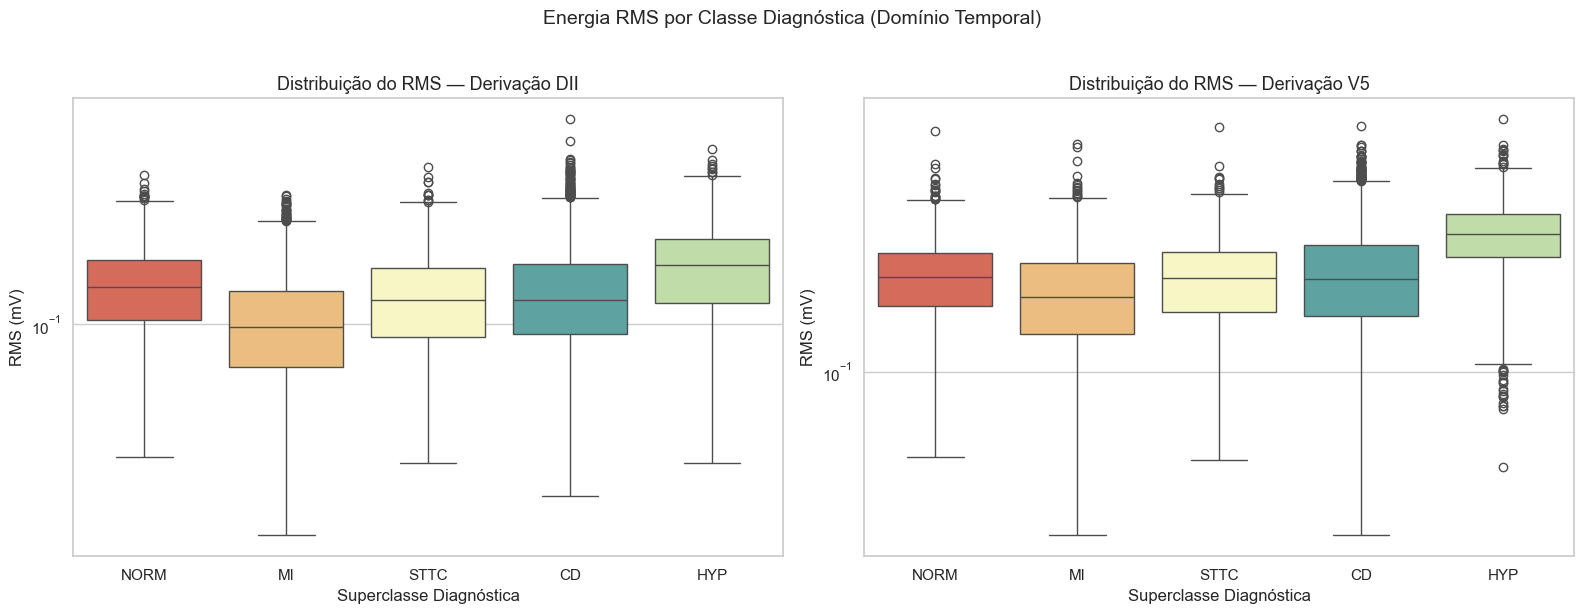


### RMS — Derivação DII
            n     mean      std      min       q1   median       q3      max  lower_whisker  upper_whisker
label                                                                                                     
NORM   7193.0  0.12912  0.03397  0.04124  0.10292  0.12858  0.15351  0.27187        0.02702        0.22941
MI     2594.0  0.10255  0.03569  0.02436  0.07522  0.09815  0.12529  0.23703        0.00010        0.20041
STTC   2017.0  0.12070  0.03726  0.03946  0.09163  0.11760  0.14580  0.28595        0.01039        0.22704
CD     4007.0  0.12425  0.04257  0.03166  0.09356  0.11748  0.14988  0.39518        0.00907        0.23437
HYP    1617.0  0.14765  0.04434  0.03948  0.11534  0.14876  0.17765  0.32426        0.02188        0.27111

### RMS — Derivação V5
            n     mean      std      min       q1   median       q3      max  lower_whisker  upper_whisker
label                                                                                          

In [5]:
# Código para efetuação de boxplots e tabela de valores por derivação e classe

# Preparação do DataFrame para plot
df_plot_time = df_time[['time_rms_II', 'time_rms_V5']].copy()

# Extração do label primário (primeira superclasse)
def get_primary(x):
    if isinstance(x, list) and len(x) > 0:
        return x[0]
    return 'OUTRO'

df_plot_time['label'] = df_reg_ids['superclasses_clean'].apply(get_primary)
order_classes = ['NORM', 'MI', 'STTC', 'CD', 'HYP']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, col, lead_name in zip(axes,
                               ['time_rms_II', 'time_rms_V5'],
                               ['DII', 'V5']):
    df_tmp = df_plot_time[df_plot_time['label'].isin(order_classes)]
    sns.boxplot(data=df_tmp, x='label', y=col, order=order_classes,
                hue='label', palette='Spectral', legend=False, ax=ax)
    ax.set_title(f'Distribuição do RMS — Derivação {lead_name}', fontsize=13)
    ax.set_xlabel('Superclasse Diagnóstica')
    ax.set_ylabel('RMS (mV)')
    ax.set_yscale('log')

plt.suptitle('Energia RMS por Classe Diagnóstica (Domínio Temporal)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'time_rms_por_classe.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabela resumo 
def summarize_boxplot(df, col, order):
    summary = (
        df[df['label'].isin(order)]
        .groupby('label')[col]
        .describe(percentiles=[0.25, 0.5, 0.75])
        .rename(columns={
            'count': 'n',
            '25%': 'q1',
            '50%': 'median',
            '75%': 'q3'
        })
    )

    # IQR e limites estilo boxplot (1.5 * IQR)
    summary['iqr'] = summary['q3'] - summary['q1']
    summary['lower_whisker'] = summary['q1'] - 1.5 * summary['iqr']
    summary['upper_whisker'] = summary['q3'] + 1.5 * summary['iqr']

    # Reordenar
    summary = summary.loc[order]

    return summary[['n', 'mean', 'std', 'min', 'q1', 'median', 'q3', 'max',
                    'lower_whisker', 'upper_whisker']]

# Gerar tabelas
summary_II = summarize_boxplot(df_plot_time, 'time_rms_II', order_classes)
summary_V5 = summarize_boxplot(df_plot_time, 'time_rms_V5', order_classes)

print("\n### RMS — Derivação DII")
print(summary_II.round(5).to_string())

print("\n### RMS — Derivação V5")
print(summary_V5.round(5).to_string())

**Comentário da subseção 2.3:**

A análise das distribuições de RMS nas derivações DII e V5 evidencia diferenças entre classes diagnósticas, porém com graus variados de separabilidade e sobreposição, refletindo limitações importantes dessa feature quando utilizada isoladamente.

- **HYP:** a classe **HYP** apresenta, de fato, medianas de RMS superiores às demais, com separação mais evidente na derivação **V5**, onde a diferença entre quartis é mais pronunciada. Esse comportamento é consistente com a fisiologia da hipertrofia ventricular esquerda. No entanto, a presença de sobreposição entre os intervalos interquartis indica que essa separação não é completamente discriminativa.

- **MI:** a classe **MI** apresenta valores de RMS sistematicamente inferiores aos demais, o que é coerente com a redução de massa miocárdica ativa. Ainda assim, observa-se **sobreposição relevante entre as distribuições**, embora menor do que aquela observada entre NORM e outras classes. Isso sugere que o RMS possui algum poder discriminativo nesse caso, mas ainda insuficiente para separação robusta, especialmente em cenários mais heterogêneos.

- **Escala e outliers:** a utilização de escala logarítmica permite melhor visualização da dispersão entre classes. Observam-se valores extremos em todas as classes, especialmente em **CD** e **HYP**, refletindo maior variabilidade. Esses outliers não parecem dominar as distribuições, mas podem indicar tanto variabilidade fisiológica quanto possíveis resíduos de artefatos.

- **DII vs. V5:** a derivação **V5** demonstra maior capacidade de separação para a classe HYP, enquanto a derivação **DII** apresenta maior sobreposição entre classes. De modo geral, ambas seguem padrões semelhantes, mas V5 se mostra mais sensível a alterações estruturais, enquanto DII apresenta menor poder discriminativo isolado.

Por fim, destaca-se que a classe **NORM apresenta maior sobreposição com CD e STTC do que com MI e HYP**, sugerindo que alterações de condução e repolarização podem preservar a energia global do sinal. Em conjunto, os resultados indicam que, embora o RMS seja uma feature informativa e fisiologicamente interpretável, sua capacidade discriminativa é limitada, justificando o uso de atributos complementares em outros domínios para uma classificação mais robusta.

---

## Seção 3 — Domínio da Frequência: PSD via Welch (12 Derivações)

### 3.1 Fundamentação

O método de **Welch** estima a Densidade Espectral de Potência (PSD) de forma estatisticamente robusta ao dividir o sinal em segmentos sobrepostos, calcular o periodograma de cada segmento e fazer a média. Comparado à FFT simples, o método de Welch reduz significativamente a variância da estimativa espectral — especialmente relevante para sinais biológicos que apresentam comportamento não-estacionário em escala global, mas podem ser considerados aproximadamente estacionários em janelas curtas, o que justifica o uso do método de Welch.

Os parâmetros utilizados:
- **`nperseg = 256` (2,56 s):** janela longa o suficiente para boa resolução em frequência (resolução de ~0,39 Hz), mas curta o suficiente para capturar variações temporais relevantes do ECG.
- **`noverlap = 128` (50%):** sobreposição padrão que equilibra o compromisso entre variância reduzida e suavização excessiva.
- **Janela de Hann:** evita o *spectral leakage* que ocorre quando o sinal não é periódico dentro da janela.

As bandas fisiológicas integradas são escolhidas com base na literatura de análise espectral de ECG:

| Banda | Faixa (Hz) | Ondas Associadas |
|---|---|---|
| PT Band (P e T) | 0,5 – 5 Hz | Onda P, onda T, possível resíduo de drift lento |
| QRS Band | 5 – 25 Hz | faixa que captura a maior parte da energia do complexo QRS (ativação ventricular), com margem para variações morfológicas entre indivíduos |
| Total Power | 0,5 – 40 Hz | Energia espectral total do sinal útil |

Além da potência por banda, extraímos três **descritores de forma da PSD**, que caracterizam a distribuição espectral sem depender de limiares de banda arbitrários:

- **Frequência de Pico:** frequência com maior densidade de potência — indica onde está concentrada a energia dominante do sinal.
- **Frequência Mediana:** frequência que divide a potência total em duas metades iguais — menos sensível a picos isolados que a frequência de pico.
- **Centroide Espectral:** centro de massa do espectro ponderado pela PSD — integra informação de toda a distribuição espectral.

### 3.2 Implementação

In [6]:
def extract_freq_domain(sig_12l, fs=FS):
    """
    Calcula PSD via Welch e extrai potência em bandas e descritores espectrais.

    Parâmetros:
    - sig_12l : array (1000, 12) — registro de 10s com 12 derivações
    - fs      : frequência de amostragem (Hz)

    Retorna:
    - feats : dicionário com as features espectrais
    """
    feats = {}
    for i, lead in enumerate(LEAD_NAMES):
        s = sig_12l[:, i].astype(np.float64)

        # Estimação da PSD via Welch
        # nperseg=256 → janela de 2,56s → resolução em freq de ~0,39 Hz
        f, psd = signal.welch(s, fs=fs, window='hann',
                               nperseg=256, noverlap=128)

        # Segurança: evita divisão por zero em sinais com potência nula
        total_pwr = np.trapezoid(psd[(f >= 0.5) & (f <= 40)],
                              f[(f >= 0.5) & (f <= 40)])
        if total_pwr == 0:
            total_pwr = np.finfo(float).eps

        # 1. Potência em bandas fisiológicas (integração trapezoidal)
        mask_pt  = (f >= 0.5) & (f <= 5.0)
        mask_qrs = (f >= 5.0) & (f <= 25.0)
        mask_tot = (f >= 0.5) & (f <= 40.0)

        feats[f'freq_pt_power_{lead}']    = np.trapezoid(psd[mask_pt],  f[mask_pt])
        feats[f'freq_qrs_power_{lead}']   = np.trapezoid(psd[mask_qrs], f[mask_qrs])
        feats[f'freq_total_power_{lead}'] = total_pwr

        # 2. Razão QRS/Total (feature relativa, mais robusta a escala absoluta)
        feats[f'freq_qrs_ratio_{lead}'] = (
            feats[f'freq_qrs_power_{lead}'] / total_pwr
        )

        # 3. Descritores de forma da PSD
        psd_nz = psd[mask_tot]
        f_nz   = f[mask_tot]

        df = f_nz[1] - f_nz[0]
        cumsum = np.cumsum(psd_nz) * df
        total = np.sum(psd_nz) * df

        feats[f'freq_peak_{lead}']     = float(f_nz[np.argmax(psd_nz)])
        feats[f'freq_median_{lead}'] = float(
            f_nz[np.where(cumsum >= total / 2)[0][0]]
        )
        feats[f'freq_centroid_{lead}'] = float(
            np.sum(f_nz * psd_nz) / np.sum(psd_nz)
        )

    return feats


print("Processando Domínio da Frequência em paralelo...")
freq_feats_list = Parallel(n_jobs=-1)(
    delayed(extract_freq_domain)(sinais_10s[i])
    for i in tqdm(range(len(df_reg_ids)), desc='Frequência')
)

df_freq = pd.DataFrame(freq_feats_list, index=df_reg_ids.index)

del freq_feats_list
gc.collect()

print(f"\nFeatures espectrais extraídas: {df_freq.shape[1]} colunas")
display(df_freq.describe().T[['mean', 'std', 'min', 'max']].head(10))

Processando Domínio da Frequência em paralelo...


Frequência: 100%|██████████| 17744/17744 [01:20<00:00, 221.31it/s]



Features espectrais extraídas: 84 colunas


,mean,std,min,max
freq_pt_power_I,0.006052,0.006929,0.000090,0.089114
freq_qrs_power_I,0.010402,0.006594,0.000243,0.055807
freq_total_power_I,0.017524,0.012178,0.000452,0.141173
freq_qrs_ratio_I,0.608508,0.121748,0.073802,0.899907
freq_peak_I,3.573633,1.956712,0.781250,20.312500
freq_median_I,7.735758,2.333540,1.171875,19.921875
freq_centroid_I,9.385217,2.176923,2.677476,19.543742
freq_pt_power_II,0.006064,0.006481,0.000146,0.133713
freq_qrs_power_II,0.009669,0.006340,0.000182,0.048833
freq_total_power_II,0.016821,0.011117,0.000529,0.140571


### 3.3 Visualização: PSD Média por Classe Diagnóstica

O gráfico abaixo mostra a **PSD média estimada na derivação DII** para cada superclasse diagnóstica. Esta visualização é fundamental para validar a separabilidade espectral entre as classes antes da classificação.

Padrões esperados:
- **CD (Distúrbio de Condução):** bloqueios de ramo alargam o complexo QRS, aumentando energia nas frequências mais baixas do espectro QRS (em torno de 5-10 Hz).
- **HYP:** maior amplitude das deflexões eleva a potência total, especialmente nas bandas de maior energia da onda R.
- **STTC (Alteração de ST-T):** alterações na onda T modificam a razão entre a banda PT e a banda QRS.

[Inserir análise comparativa das curvas — verificar se as diferenças entre classes são clinicamente coerentes e estatisticamente expressivas.]

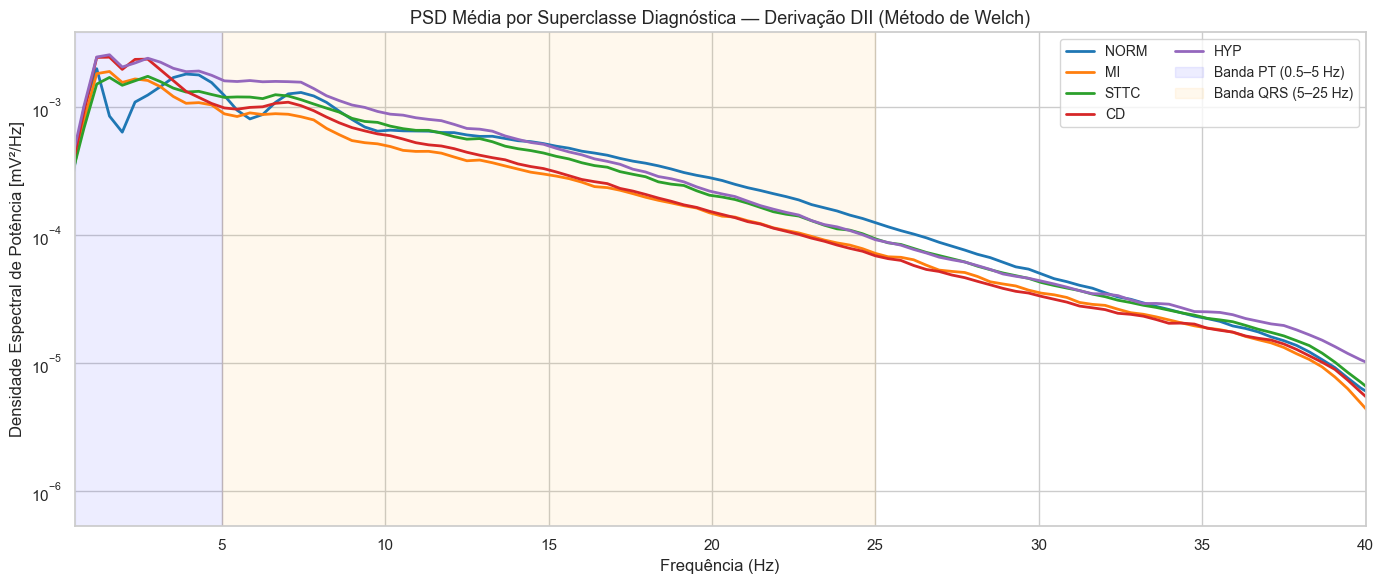

In [7]:
# Cálculo das PSDs médias por classe para visualização

def get_psd_mean_per_class(sinais_arr, df_meta, classes_target, fs=FS, lead_idx=1):
    """
    Calcula a PSD média via Welch para um subconjunto de registros por classe.
    Lead_idx=1 corresponde à derivação DII.
    """
    results = {}
    for cls in classes_target:
        ids_cls = df_meta[
            df_meta['superclasses_clean'].apply(
                lambda x: cls in x if isinstance(x, list) else False
            )
        ].index[:3000]  # limitamos a 3000 por classe para velocidade

        psds = []
        for eid in ids_cls:
            pos = df_meta.index.get_loc(eid)
            s = sinais_arr[pos, :, lead_idx].astype(np.float64)
            f, p = signal.welch(s, fs=fs, window='hann', nperseg=256, noverlap=128)
            psds.append(p)

        if psds:
            results[cls] = (f, np.mean(np.array(psds), axis=0))

    return results

classes_target = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
psd_por_classe = get_psd_mean_per_class(sinais_10s, df_reg_ids, classes_target)

fig, ax = plt.subplots(figsize=(14, 6))
palette = sns.color_palette('tab10', n_colors=len(classes_target))

for (cls, (f_arr, psd_mean)), cor in zip(psd_por_classe.items(), palette):
    ax.semilogy(f_arr, psd_mean, label=cls, color=cor, linewidth=2)

# Marcação das bandas fisiológicas
ax.axvspan(0.5, 5,  alpha=0.07, color='blue',  label='Banda PT (0.5–5 Hz)')
ax.axvspan(5,  25,  alpha=0.07, color='orange', label='Banda QRS (5–25 Hz)')
ax.set_xlim(0.5, 40)
ax.set_xlabel('Frequência (Hz)')
ax.set_ylabel('Densidade Espectral de Potência [mV²/Hz]')
ax.set_title('PSD Média por Superclasse Diagnóstica — Derivação DII (Método de Welch)', fontsize=13)
ax.legend(fontsize=10, ncol=2)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'freq_psd_media_por_classe.png', dpi=150, bbox_inches='tight')
plt.show()

**Comentário da subseção 3.3:**

* **Formato geral das curvas:** a classe NORM apresenta o comportamento espectral esperado, com maior concentração de energia na banda do QRS e decaimento progressivo nas frequências mais altas. Observa-se, contudo, a presença de múltiplos picos locais (em torno de ~4–8 Hz), sugerindo que a energia não está concentrada em uma única frequência dominante, mas distribuída ao longo da transição entre as bandas PT e QRS. As demais classes apresentam maior concentração relativa de energia nas baixas frequências (≈0,5–3 Hz), com decaimento mais suave ao longo do espectro.

* **MI (Infarto do Miocárdio):** a classe MI apresenta, de forma consistente, menor densidade espectral de potência ao longo de praticamente toda a faixa analisada. Esse comportamento é compatível com a redução da atividade elétrica efetiva em regiões comprometidas do miocárdio, resultando em menor energia global do sinal. A separação visual em relação às demais classes é relativamente clara em termos de magnitude absoluta, embora menos evidente em termos de forma espectral.

* **CD (Distúrbio de Condução / Bloqueios de Ramo):** observa-se um deslocamento da energia espectral para frequências mais baixas em relação à NORM, com maior concentração abaixo de ~5 Hz. Esse comportamento é coerente com o alargamento do complexo QRS, que reduz o conteúdo de alta frequência. O pico observado em ~2–3 Hz sugere que esse deslocamento não se limita à faixa clássica de 5–10 Hz, mas envolve uma redistribuição mais ampla da energia para regiões ainda mais baixas do espectro.

* **HYP (Hipertrofia):** a classe HYP apresenta maior densidade espectral de potência na maior parte do espectro, especialmente nas baixas e médias frequências (≈0,5–15 Hz), o que está alinhado com o aumento da amplitude das deflexões cardíacas. Entretanto, em frequências mais elevadas (>15 Hz), observa-se que a classe NORM pode apresentar valores superiores em determinados intervalos (até ~30–32 Hz), indicando que o aumento de energia em HYP não é uniforme em todo o espectro.

* **STTC (Alterações de ST-T):** a classe STTC apresenta comportamento intermediário, com leve elevação relativa na banda de baixas frequências (0,5–5 Hz), possivelmente associada a alterações na onda T. No entanto, há forte sobreposição com outras classes nessa e em faixas maiores (hora com HYP, hora com CD e MI), sugerindo que essa característica isoladamente possui baixo poder discriminativo.

* **Sobreposição entre classes:** há sobreposição significativa entre as classes diagnósticas ao longo de grande parte do espectro. A classe NORM se destaca por apresentar maior irregularidade na faixa de ~0,5–10 Hz e por tender a assumir valores relativamente mais altos nas frequências superiores (~10–35 Hz). As regiões de maior separabilidade concentram-se nas baixas frequências (≈0,5–5 Hz) e na magnitude global da PSD, onde HYP tende a apresentar maior potência e MI menor. Esses achados indicam que features baseadas apenas em potência absoluta são insuficientes, reforçando a necessidade de descritores espectrais adicionais (como razão entre bandas e métricas de forma da PSD) para melhor discriminação no Entregável 9.


---

## Seção 4 — Morfologia de Ondas e Variabilidade de Ritmo (HRV)

### 4.1 Fundamentação

Esta seção opera sobre os **batimentos segmentados** produzidos no Entregável 5 — janelas de 600 ms (60 amostras a 100 Hz) centradas no pico R de cada batimento detectado pelo algoritmo Pan-Tompkins.

A análise em dois sub-grupos:

#### A. Morfologia das Ondas Cardíacas

Cada batimento individual permite medir grandezas morfológicas que, sobre o sinal de 10 s inteiro, seriam difíceis de isolar com precisão:

- **Amplitude R:** valor de pico da onda R (máximo da janela centrada no complexo QRS). Reduzida em infarto transmural pela perda de massa miocárdica; elevada em hipertrofia ventricular.
- **Duração do QRS:** largura estimada do complexo QRS por cruzamento de limiar. Alargamento (> 120 ms) é característico de bloqueios de ramo.
- **Segmento ST:** amplitude média no trecho pós-QRS (aprox. 60-120 ms após o pico R, equivalente a amostras 36-46). Elevação > 1 mm indica lesão aguda; depressão indica isquemia subendocárdica.
- **Amplitude T:** pico da onda T na porção final da janela (amostras 40-60). Onda T invertida em derivações precordiais pode indicar isquemia ou sobrecarga ventricular.

Os valores são extraídos **por batimento** e depois **agregados ao nível do registro** via mediana (robusta a batimentos outliers) e desvio padrão (captura variabilidade batimento a batimento).

#### B. Métricas de Variabilidade de Ritmo Cardíaco (HRV — Domínio do Tempo)

A variabilidade do intervalo RR — extraída da série de intervalos entre picos R consecutivos — é um dos indicadores fisiológicos mais estudados em cardiologia. Reflete o balanço autonômico entre a atividade simpática (reduz a variabilidade) e parassimpática (aumenta a variabilidade).

Métricas temporais de HRV extraídas:

| Métrica | Fórmula | Interpretação Clínica |
|---|---|---|
| meanRR | $\overline{RR}$ | Frequência cardíaca média |
| SDRR | $\sigma_{RR}$ | Variabilidade global do ritmo |
| RMSSD | $\sqrt{\overline{(\Delta RR_i)^2}}$ | Variabilidade de curto prazo (tônus vagal) |
| CV_RR | $\sigma_{RR} / \overline{RR}$ | Variabilidade normalizada pela FC média |

.

> **Nota sobre RMSSD:** é calculado sobre as diferenças **consecutivas** entre intervalos RR, capturando flutuações de curto prazo. É o índice temporal de HRV com maior associação à atividade parassimpática e ao tônus vagal, sendo amplamente utilizado em análises de saúde cardiovascular e monitoramento de estresse.

### 4.2 Implementação — Extração por Batimento

In [8]:
# Extração de features morfológicas por batimento

def extract_morph_per_beat(beat_12l):
    """
    Extrai features morfológicas de um único batimento (60 amostras = 600 ms a 100 Hz).

    Derivações analisadas:
    - DII (índice 1)
    - V5 (índice 10)
    """
    feats = {}

    for l_idx, l_name in [(1, 'II'), (10, 'V5')]:
        s = beat_12l[:, l_idx].astype(np.float64)
        n = len(s)

        # --- Pico R ---
        peak_idx = int(np.argmax(s))
        peak_val = s[peak_idx]
        feats[f'morph_r_amp_{l_name}'] = float(peak_val)

        # --- QRS width (robusto) ---
        thresh = np.abs(peak_val) * 0.15

        left_bound  = max(0, peak_idx - 10)
        right_bound = min(n, peak_idx + 10)

        window = s[left_bound:right_bound]
        idxs = np.where(np.abs(window) > thresh)[0]

        if len(idxs) >= 2:
            qrs_width = (idxs[-1] - idxs[0]) * 10  # 10 ms por amostra
        else:
            qrs_width = 80.0  # fallback fisiológico

        feats[f'morph_qrs_width_ms_{l_name}'] = float(qrs_width)

        # --- Segmento ST (com proteção de borda) ---
        st_start = min(n, peak_idx + 6)
        st_end   = min(n, peak_idx + 16)

        if st_end > st_start:
            feats[f'morph_st_amp_{l_name}'] = float(np.mean(s[st_start:st_end]))
        else:
            feats[f'morph_st_amp_{l_name}'] = np.nan

        # --- Onda T (heurística robusta) ---
        if n > 40:
            t_segment = s[40:]
            feats[f'morph_t_amp_{l_name}'] = float(
                t_segment[np.argmax(np.abs(t_segment))]
            )
        else:
            feats[f'morph_t_amp_{l_name}'] = np.nan

        # --- Assimetria do QRS ---
        left  = s[max(0, peak_idx - 10):peak_idx]
        right = s[peak_idx:min(n, peak_idx + 10)]

        if len(left) > 0 and len(right) > 0:
            den = np.mean(np.abs(right))
            if den > 1e-6:
                asym = np.mean(np.abs(left)) / den
            else:
                asym = np.nan
        else:
            asym = np.nan

        feats[f'morph_qrs_asym_{l_name}'] = float(asym)

    return feats


print("Processando morfologia individual dos batimentos em paralelo...")
morph_list = Parallel(n_jobs=-1)(
    delayed(extract_morph_per_beat)(batimentos[i])
    for i in tqdm(range(len(batimentos)), desc='Morfologia')
)

df_morph_all = pd.DataFrame(morph_list)
print(f"Morfologia individual: {df_morph_all.shape[0]} batimentos × {df_morph_all.shape[1]} features")



Processando morfologia individual dos batimentos em paralelo...


Morfologia: 100%|██████████| 211442/211442 [00:31<00:00, 6815.25it/s]


Morfologia individual: 211442 batimentos × 10 features


### 4.3 Implementação — Agregação ao Nível do Registro e HRV

In [9]:
# Associar cada batimento ao seu ecg_id e ao intervalo RR correspondente
df_morph_meta = pd.concat(
    [df_beat_ids[['ecg_id', 'rr_interval_ms']].reset_index(drop=True),
     df_morph_all.reset_index(drop=True)],
    axis=1
)

# ── A. Métricas de HRV (domínio do tempo) ──────────────────────────────────
def rmssd(x):
    """
    Calcula RMSSD sobre uma série de intervalos RR.
    Requer ao menos 2 valores não-nulos para calcular diferenças consecutivas.
    """
    s = x.dropna()
    if len(s) < 2:
        return np.nan
    return float(np.sqrt(np.mean(np.diff(s.values) ** 2)))

def cv_rr(x):
    """
    Coeficiente de variação dos intervalos RR.
    Normaliza a variabilidade pela FC média, permitindo comparação entre
    registros com frequências cardíacas diferentes.
    """
    mu = x.mean()
    return float(x.std() / mu) if mu != 0 else np.nan

df_hrv = df_morph_meta.groupby('ecg_id')['rr_interval_ms'].agg(
    hrv_meanRR = 'mean',
    hrv_sdRR   = 'std',
    hrv_rmssd  = rmssd,
    hrv_cvRR   = cv_rr,
    hrv_n_beats = 'count',   # Número de batimentos detectados no registro
)

# ── B. Agregação morfológica (Mediana + STD por registro) ───────────────────
# Mediana: robusta a batimentos individuais com valores extremos (artefatos residuais)
# STD: captura variabilidade batimento a batimento (ex: alternância elétrica, arritmias)
morph_cols = [c for c in df_morph_all.columns]
agg_rules  = {col: ['median', 'std'] for col in morph_cols}

df_morph_agg = df_morph_meta.groupby('ecg_id').agg(agg_rules)
df_morph_agg.columns = ['_'.join(col).strip() for col in df_morph_agg.columns.values]

# ── C. Unificação HRV + Morfologia ─────────────────────────────────────────
df_beat_final = df_hrv.join(df_morph_agg, how='left')

del morph_list, df_morph_all, df_morph_meta
gc.collect()

print(f"Features de morfologia e HRV agregadas: {df_beat_final.shape}")
print(f"  → {len(df_hrv.columns)} features de HRV")
print(f"  → {len(df_morph_agg.columns)} features morfológicas (mediana + STD)")
display(df_beat_final.head(3))

Features de morfologia e HRV agregadas: (17744, 25)
  → 5 features de HRV
  → 20 features morfológicas (mediana + STD)


,hrv_meanRR,hrv_sdRR,hrv_rmssd,hrv_cvRR,hrv_n_beats,morph_r_amp_II_median,morph_r_amp_II_std,morph_qrs_width_ms_II_median,morph_qrs_width_ms_II_std,morph_st_amp_II_median,...,morph_r_amp_V5_median,morph_r_amp_V5_std,morph_qrs_width_ms_V5_median,morph_qrs_width_ms_V5_std,morph_st_amp_V5_median,morph_st_amp_V5_std,morph_t_amp_V5_median,morph_t_amp_V5_std,morph_qrs_asym_V5_median,morph_qrs_asym_V5_std
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,940.000000,21.794495,35.000000,0.023186,9,0.356700,0.025515,150.0,38.815804,-0.036932,...,0.489677,0.026409,55.0,24.404007,-0.046563,0.008505,0.184063,0.020268,0.514794,0.155566
4,798.333333,44.278731,38.138504,0.055464,12,0.836251,0.000000,110.0,58.127342,-0.085157,...,1.477132,0.000000,60.0,19.128750,-0.095020,0.022459,0.591531,0.032895,0.381531,0.116496
5,906.000000,51.251016,57.735027,0.056568,10,0.836251,0.000000,130.0,39.519845,-0.098841,...,1.293118,0.059420,20.0,6.466698,-0.090401,0.015201,0.296740,0.022733,0.411245,0.160028


### 4.4 Visualização: HRV e Morfologia por Classe Diagnóstica

Os gráficos a seguir examinam a separabilidade entre as classes diagnósticas para as features morfológicas e de HRV.

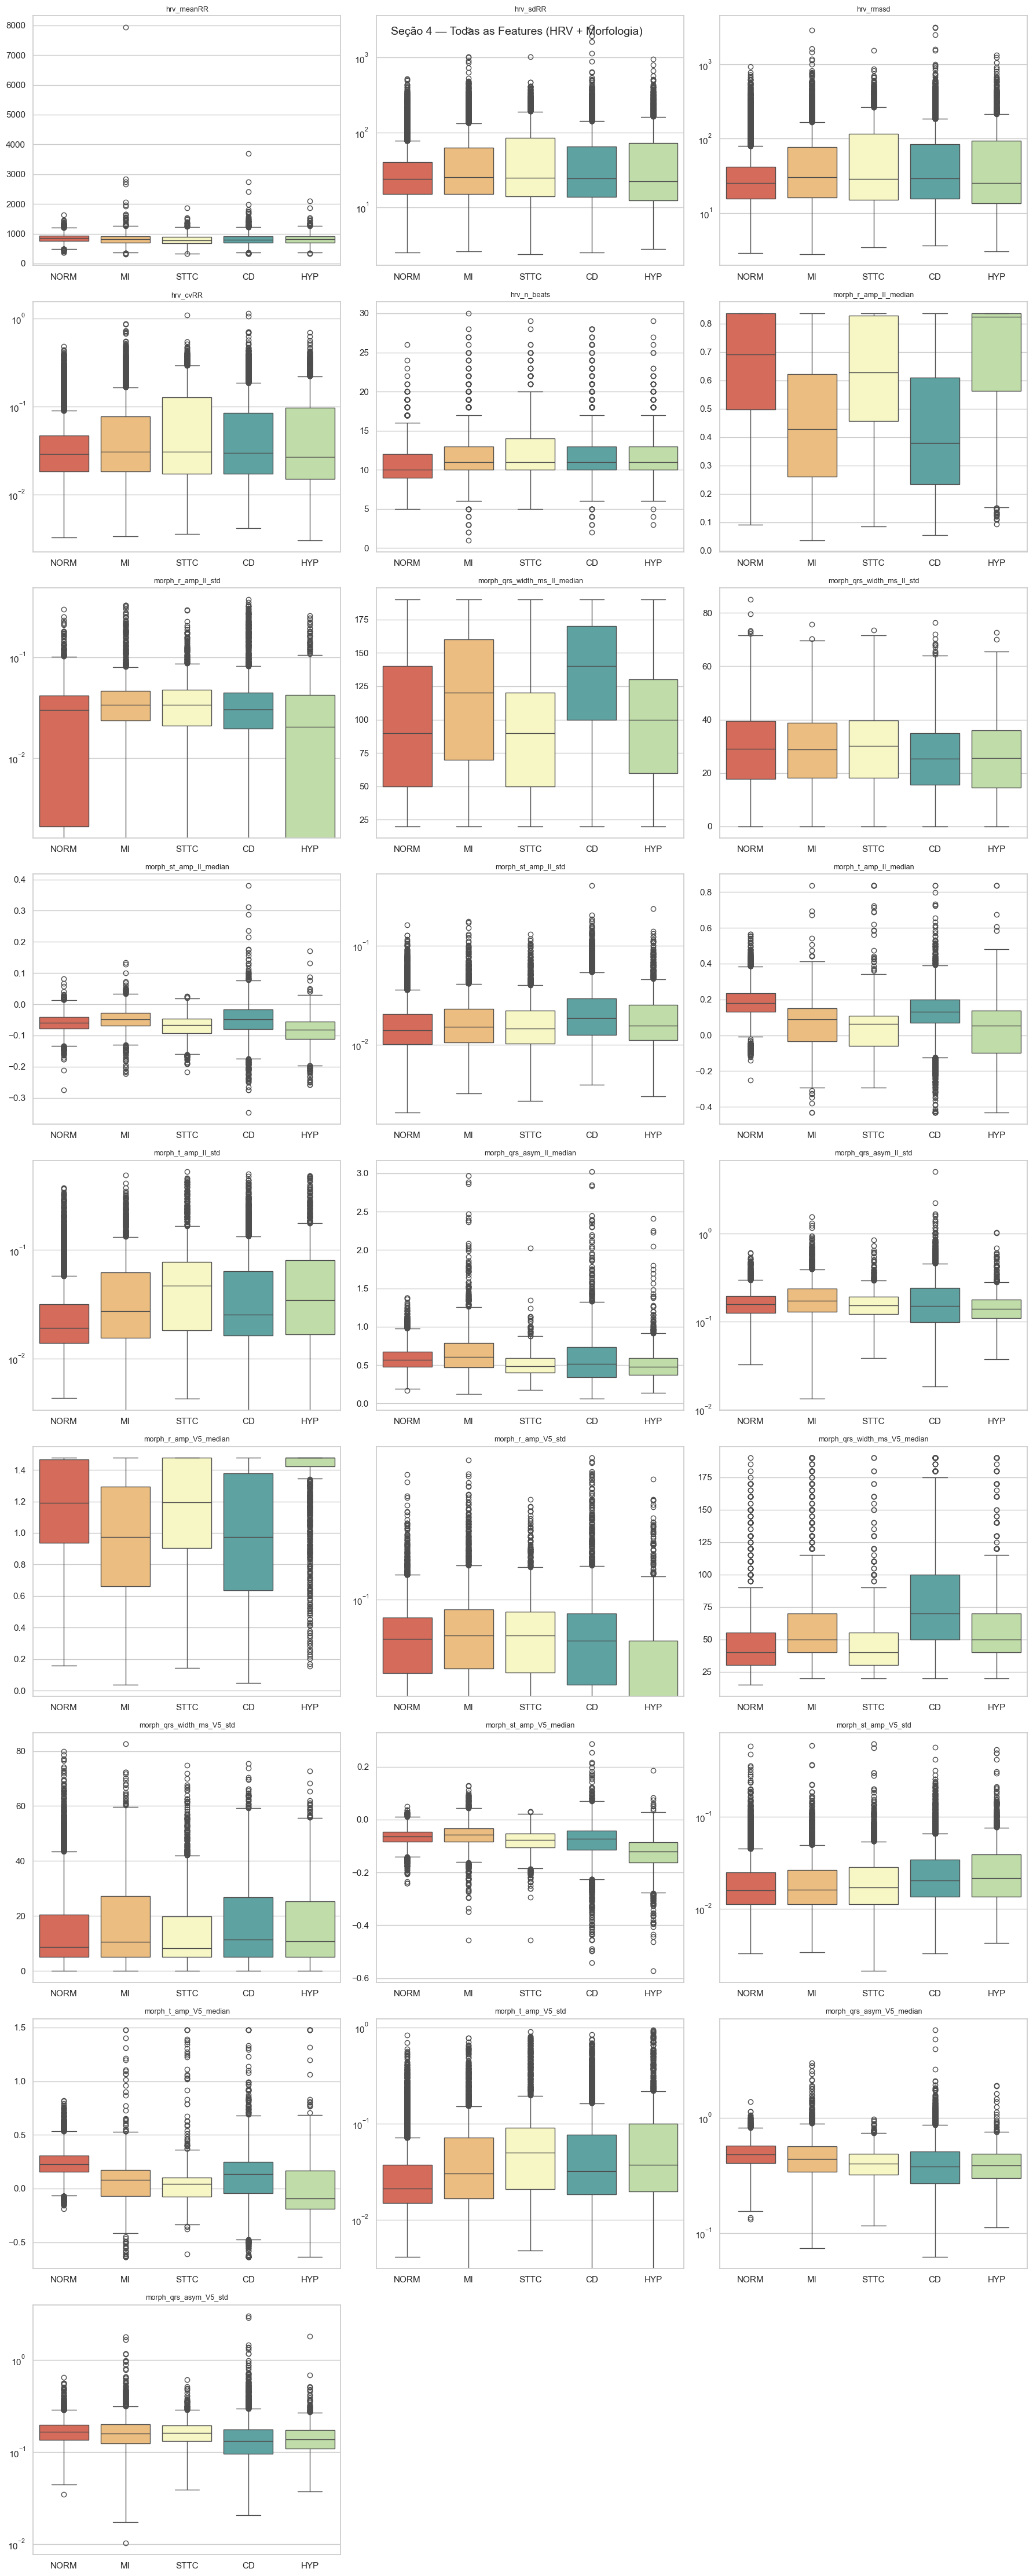

In [10]:
# Visualização: HRV e Morfologia por Classe Diagnóstica

# Preparação
classes_target = ['NORM', 'MI', 'STTC', 'CD', 'HYP']

df_beat_plot = df_beat_final.copy()
df_beat_plot['label'] = df_reg_ids['superclasses_clean'].apply(get_primary)
df_beat_plot = df_beat_plot[df_beat_plot['label'].isin(classes_target)]

# Lista de features (todas exceto label)
feature_cols = [c for c in df_beat_plot.columns if c != 'label']

# Grid manual (3 colunas)
n_cols = 3
n_rows = (len(feature_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]

    sns.boxplot(
        data=df_beat_plot,
        x='label',
        y=col,
        order=classes_target,
        hue='label',
        palette='Spectral',
        legend=False,
        ax=ax
    )

    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel('')

    # Log automático pra evitar gráfico "achatado"
    try:
        if df_beat_plot[col].median() > 0 and df_beat_plot[col].max() > 10 * df_beat_plot[col].median():
            ax.set_yscale('log')
    except:
        pass

# Remove eixos extras
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Seção 4 — Todas as Features (HRV + Morfologia)', fontsize=14)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'secao4_boxplots_todos.png', dpi=150, bbox_inches='tight')
plt.show()

**Comentário da Subseção 4.4:**

A análise dos boxplots evidencia que uma parcela significativa das métricas extraídas apresenta baixa capacidade discriminativa entre as classes diagnósticas. Em particular, diversas features exibem distribuições altamente sobrepostas, com medianas e intervalos interquartis muito próximos, o que limita sua utilidade isolada em tarefas de classificação. Esse comportamento é especialmente evidente nas métricas de HRV, sugerindo que, para este conjunto de dados e janela temporal (10 s), a variabilidade do ritmo cardíaco possui baixo poder de separação entre as superclasses consideradas.

Entre as métricas de HRV, destaca-se apenas *hrv_n_beats*, que apresenta uma leve diferenciação entre classes, com registros da classe **NORM** tendendo a apresentar menor número de batimentos em comparação às classes patológicas. Ainda assim, essa separação não é suficientemente expressiva para ser considerada robusta de forma isolada.

Por outro lado, as métricas morfológicas demonstram maior potencial discriminativo, sobretudo aquelas associadas à amplitude e duração de componentes específicos do ECG:

* *morph_r_amp_V5_median:* observa-se que as classes **MI** e **CD** tendem a apresentar valores mais baixos de amplitude R em V5, com seus quartis superiores frequentemente abaixo das medianas das demais classes. Esse comportamento é consistente com a redução da atividade elétrica efetiva (MI) e alterações na propagação ventricular (CD).

* *morph_t_amp_* (DII e V5): a amplitude da onda T apresenta destaque para a classe **NORM**, com medianas superiores às demais, enquanto **CD** também demonstra leve elevação relativa. Ainda assim, há sobreposição relevante, indicando que essa feature pode ser mais útil em combinação com outras do que isoladamente.

* *morph_r_amp_V5_median (HYP):* a classe **HYP** apresenta valores sistematicamente mais elevados e menor dispersão relativa (intervalo interquartil mais concentrado em valores altos), refletindo o aumento da massa ventricular esquerda. Apesar da separação visual ser bastante expressiva, ainda há alguma sobreposição nas caudas das distribuições, o que recomenda cautela em interpretações determinísticas.

* *morph_qrs_width_ms_V5_median:* esta é uma das features mais discriminativas observadas, com a classe **CD** apresentando valores significativamente superiores às demais. A mediana e o primeiro quartil de **CD** frequentemente excedem os quartis superiores das outras classes, o que está alinhado com o alargamento do complexo QRS característico de distúrbios de condução.

De forma geral, os resultados indicam que a maior capacidade de separação entre classes nesta seção está concentrada em atributos morfológicos diretamente relacionados à fisiologia elétrica ventricular (amplitude e duração do QRS), enquanto métricas de variabilidade de ritmo apresentam contribuição limitada. Além disso, a distinção observada ocorre predominantemente entre subconjuntos de classes (por exemplo, **HYP vs. demais** ou **CD vs. demais**), e não de forma global entre todas as categorias.

Essas observações reforçam a necessidade de combinar essas features com descritores de outros domínios (especialmente espectral e temporal global) no Entregável 9, a fim de capturar padrões complementares e melhorar a capacidade discriminativa do modelo final.


---

## Seção 5 — Domínio Tempo-Frequência: Transformada Wavelet Discreta (DWT)

### 5.1 Fundamentação

A **Transformada Wavelet Discreta (DWT)** decompõe o sinal em sub-bandas de frequência através de um banco de filtros em cascata, preservando simultaneamente informação temporal e espectral. Diferentemente da FFT — que assume estacionaridade global — a DWT é naturalmente adaptada a sinais não-estacionários como o ECG.

#### Estrutura da Decomposição (4 Níveis, db4)

A decomposição opera aplicando iterativamente um filtro **passa-baixa** (L, que gera os coeficientes de aproximação A) e um filtro **passa-alta** (H, que gera os coeficientes de detalhe D), seguidos de subamostragem por 2:

```
Sinal original (100 Hz)
    ├── A4: coeficientes de aproximação nível 4  → 0–6,25 Hz  (onda P, T, drift)
    ├── D4: detalhe nível 4                      → 6,25–12,5 Hz (início do QRS)
    ├── D3: detalhe nível 3                      → 12,5–25 Hz  (pico do QRS)
    ├── D2: detalhe nível 2                      → 25–50 Hz    (ruído residual)
    └── D1: detalhe nível 1                      → 50–100 Hz   (ruído de alta freq.)
```

> **Escolha da família db4 (Daubechies de ordem 4):** a wavelet-mãe db4 apresenta boa localização temporal e formato compatível com as morfologias das ondas cardíacas — sua assimetria e suavidade refletem a natureza das deflexões do ECG melhor que wavelets simétricas como a Haar.

Para cada sub-banda, extraímos:

- **Energia:** $E_k = \sum_{n} c_k[n]^2$ — quantidade de sinal presente naquela faixa de frequência. sub-bandas com maior energia concentram as estruturas dominantes do sinal.
- **Entropia de Shannon:** $H_k = -\sum_n p[n] \log_2 p[n]$, onde $p[n]$ é estimada via histograma dos coeficientes. Mede a distribuição da energia dentro da sub-banda — coeficientes concentrados (ex: pico QRS isolado) têm menor entropia que coeficientes distribuídos.

### 5.2 Implementação

In [11]:
# SEÇÃO 5 — DWT (Tempo-Frequência)

# --- Função base: DWT por derivação ---
def extract_wavelet_features(sig_lead, level=4, wavelet='db4'):
    def shannon_entropy(coefs):
        counts, _ = np.histogram(coefs, bins='auto')
        counts = counts[counts > 0]
        probs = counts / counts.sum()
        return float(entropy(probs, base=2))

    feats = {}

    coeffs = pywt.wavedec(sig_lead, wavelet=wavelet, level=level)
    band_names = [f'A{level}'] + [f'D{level - i}' for i in range(level)]

    # Energia total (CORRETO)
    total_energy = sum(np.sum(c_i ** 2) for c_i in coeffs)

    for band_name, c in zip(band_names, coeffs):
        energy = float(np.sum(c ** 2))
        ent    = shannon_entropy(c)
        norm_e = energy / (total_energy + 1e-10)

        feats[f'wavelet_energy_{band_name}']     = energy
        feats[f'wavelet_entropy_{band_name}']    = ent
        feats[f'wavelet_rel_energy_{band_name}'] = norm_e

    # Razão QRS
    e_qrs = feats['wavelet_energy_D3'] + feats['wavelet_energy_D4']
    feats['wavelet_qrs_ratio'] = float(e_qrs / (total_energy + 1e-10))

    return feats


# --- Wrapper: múltiplas derivações (DII + V5) ---
def extract_wavelet_multilead(sig_12l):
    feats = {}

    leads = [(1, 'II'), (10, 'V5')]

    for idx, name in leads:
        sig = sig_12l[:, idx].astype(np.float64)
        f_lead = extract_wavelet_features(sig)

        for k, v in f_lead.items():
            feats[f'{k}_{name}'] = v

    return feats

# EXTRAÇÃO EM LOTE
print("Processando DWT (db4, 4 níveis) em DII + V5...")

wavelet_feats_list = Parallel(n_jobs=-1)(
    delayed(extract_wavelet_multilead)(sinais_10s[i])
    for i in tqdm(range(len(df_reg_ids)), desc='Wavelet')
)

df_wavelet = pd.DataFrame(wavelet_feats_list, index=df_reg_ids.index)

del wavelet_feats_list
gc.collect()

print(f"\nFeatures Wavelet extraídas: {df_wavelet.shape[1]} colunas")
display(df_wavelet.describe().T[['mean', 'std', 'min', 'max']].head(10))

Processando DWT (db4, 4 níveis) em DII + V5...


Wavelet: 100%|██████████| 17744/17744 [00:33<00:00, 522.57it/s]



Features Wavelet extraídas: 32 colunas


,mean,std,min,max
wavelet_energy_A4_II,5.098783,6.295236,0.134237,128.978780
wavelet_entropy_A4_II,2.743965,0.164817,1.627141,3.411195
wavelet_rel_energy_A4_II,0.265911,0.143787,0.014615,0.867461
wavelet_energy_D4_II,4.165841,3.355776,0.093893,41.835291
wavelet_entropy_D4_II,2.828566,0.143547,1.657400,3.455643
wavelet_rel_energy_D4_II,0.218092,0.075518,0.023966,0.676648
wavelet_energy_D3_II,4.806272,3.408882,0.078848,29.191558
wavelet_entropy_D3_II,3.001108,0.285045,1.549441,3.658398
wavelet_rel_energy_D3_II,0.257795,0.077847,0.018667,0.651025
wavelet_energy_D2_II,3.533357,2.443495,0.045589,18.203639


### 5.3 Visualização: Decomposição Wavelet por Classe

O painel apresenta a decomposição DWT (db4, 4 níveis) para registros representativos de cada classe, permitindo verificar a correspondência entre sub-bandas e componentes fisiológicos do ECG:

- **A4 + D4:** componentes de baixa frequência (onda P, T, drift) e início do QRS  
- **D3:** principal conteúdo do complexo QRS  
- **D2–D1:** componentes de alta frequência (ruído residual e detalhes finos do QRS)

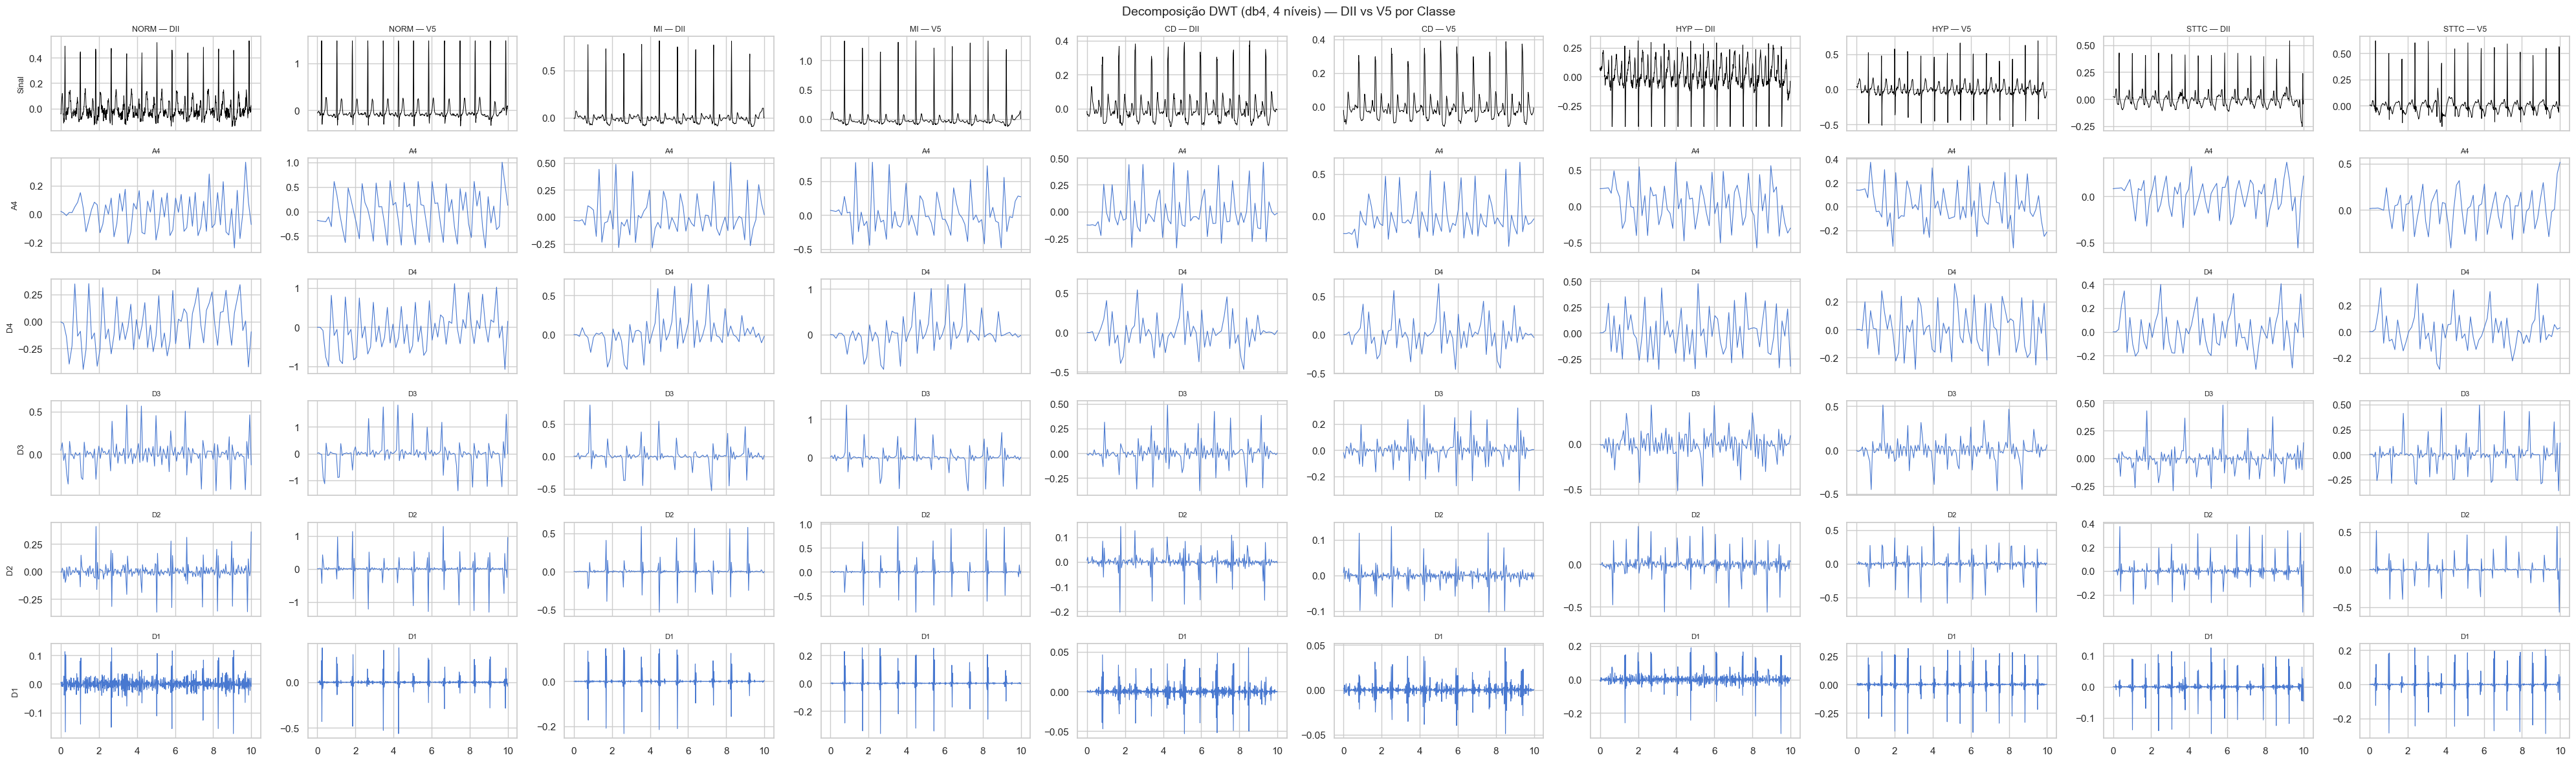

In [12]:
# 5.3 Visualização: Decomposição Wavelet (DII + V5)

def plot_dwt_decomposicao(sinal_1d, titulo, fs=FS, wavelet='db4', level=4, ax_list=None):
    coeffs = pywt.wavedec(sinal_1d, wavelet=wavelet, level=level)
    band_names = [f'A{level}'] + [f'D{level - i}' for i in range(level)]

    t = np.arange(len(sinal_1d)) / fs

    # Sinal original
    ax_list[0].plot(t, sinal_1d, color='black', lw=0.7)
    ax_list[0].set_title(f'{titulo}', fontsize=9)

    # Sub-bandas
    for j, (bname, c) in enumerate(zip(band_names, coeffs)):
        tc = np.linspace(0, len(sinal_1d)/fs, len(c))
        ax_list[j + 1].plot(tc, c, lw=0.8)
        ax_list[j + 1].set_title(bname, fontsize=8)

    return ax_list


classes_exemplo = ['NORM', 'MI', 'CD', 'HYP', 'STTC']
nivel_decomp = 4
n_rows = nivel_decomp + 2   # sinal + sub-bandas
n_cols = len(classes_exemplo) * 2  # DII + V5 para cada classe

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(4 * n_cols, 2 * n_rows),
    sharex='col'
)

for col_idx, cls in enumerate(classes_exemplo):

    ids_cls = df_reg_ids[
        df_reg_ids['superclasses_clean'].apply(
            lambda x: cls in x if isinstance(x, list) else False
        )
    ].index

    if len(ids_cls) == 0:
        continue

    # Escolha mais representativa (evita pegar outlier)
    eid = ids_cls[len(ids_cls)//2]
    pos = df_reg_ids.index.get_loc(eid)

    # --- DII ---
    sinal_dii = sinais_10s[pos, :, 1].astype(np.float64)
    col_axes_dii = axes[:, col_idx * 2]

    plot_dwt_decomposicao(
        sinal_dii,
        f'{cls} — DII',
        ax_list=col_axes_dii
    )

    # --- V5 ---
    sinal_v5 = sinais_10s[pos, :, 10].astype(np.float64)
    col_axes_v5 = axes[:, col_idx * 2 + 1]

    plot_dwt_decomposicao(
        sinal_v5,
        f'{cls} — V5',
        ax_list=col_axes_v5
    )

# Labels do eixo Y apenas na primeira coluna
labels = ['Sinal'] + [f'A{nivel_decomp}'] + [f'D{nivel_decomp - i}' for i in range(nivel_decomp)]

for i, lab in enumerate(labels):
    axes[i, 0].set_ylabel(lab, fontsize=9)

plt.suptitle('Decomposição DWT (db4, 4 níveis) — DII vs V5 por Classe', fontsize=14)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'wavelet_decomposicao_multilead.png', dpi=150, bbox_inches='tight')
plt.show()

**Comentários da subseção 5.3:**

A decomposição wavelet (db4, 4 níveis) evidencia uma separação coerente entre componentes de baixa e alta frequência do sinal de ECG, permitindo associar diretamente as sub-bandas às estruturas fisiológicas esperadas. De forma geral, observa-se que os coeficientes de detalhe D3 e D4 concentram a maior parte da energia associada ao complexo QRS, enquanto a aproximação A4 representa adequadamente as componentes mais lentas do sinal, como ondas P, T e possíveis variações de linha de base. As sub-bandas D2 e D1, por sua vez, capturam predominantemente componentes de alta frequência, associadas a ruído residual e pequenos detalhes morfológicos.

Na classe **NORM**, a *energia encontra-se bem distribuída*, com forte concentração em D3/D4 e uma componente A4 relativamente suave, indicando um padrão fisiológico estável, com complexos QRS bem definidos e pouca interferência de ruído ou irregularidades. 

Já na classe **MI**, observa-se uma redução consistente da amplitude dos coeficientes nas sub-bandas associadas ao QRS, sugerindo menor energia global do sinal, o que é compatível com a perda de tecido miocárdico funcional. Além disso, há maior irregularidade relativa nas componentes de baixa frequência, indicando possível instabilidade na morfologia das ondas.

Na classe **CD**, destaca-se um deslocamento da energia para sub-bandas de menor frequência, com maior presença em D4 e até em A4, em detrimento de D3. Esse comportamento reflete o alargamento do complexo QRS, característico de distúrbios de condução, no qual a ativação ventricular ocorre de forma mais lenta e distribuída no tempo, reduzindo o conteúdo de alta frequência do sinal.

Para a classe **HYP**, observa-se um aumento generalizado da energia em praticamente todas as sub-bandas, especialmente em D3 e D4, o que indica maior amplitude das deflexões cardíacas. Esse padrão é consistente com o aumento de massa ventricular, que resulta em sinais de maior intensidade ao longo de todo o espectro, inclusive nas componentes de baixa frequência.

A classe **STTC** apresenta diferenças mais sutis em relação às demais, com leve aumento relativo na componente A4, indicando maior contribuição de baixas frequências associadas a alterações nas ondas T. No entanto, a separação visual dessa classe é menos evidente, com significativa sobreposição em relação às demais, sobretudo nas sub-bandas associadas ao QRS.

A comparação entre as derivações DII e V5 revela comportamentos complementares. Em V5, as sub-bandas associadas ao QRS (D3/D4) apresentam maior amplitude e definição, tornando essa derivação particularmente sensível a alterações morfológicas ventriculares, como as observadas em HYP e MI. Em contrapartida, DII apresenta um comportamento mais equilibrado entre as sub-bandas, capturando melhor aspectos relacionados ao ritmo e às componentes de baixa frequência.

Em conjunto, esses resultados indicam que a DWT captura de forma consistente as transformações fisiopatológicas esperadas entre as classes diagnósticas. Embora a separação visual entre classes não seja completamente distinta em todas as sub-bandas, os padrões observados justificam o uso de features baseadas em energia, energia relativa e entropia por sub-banda, bem como razões específicas (como QRS/total), como descritores discriminativos relevantes para as etapas subsequentes de modelagem.

---

## Seção 6 — Dinâmica Não-Linear: DFA, Higuchi e Poincaré

### 6.1 Fundamentação

As métricas não-lineares capturam aspectos da dinâmica cardíaca que os domínios anteriores — baseados em estatísticas lineares de amplitude e frequência — não conseguem representar: a **complexidade geométrica** do sinal e as **correlações de longo alcance** na série temporal.

#### A. Dimensão Fractal de Higuchi (FD)

O método de Higuchi estima a dimensão fractal $D_H$ de uma série temporal construindo curvas de comprimento $L(k)$ para diferentes escalas temporais $k$ e ajustando a relação de potência:

$$L(k) \propto k^{-D_H}$$

Em sinais de ECG, valores típicos de $D_H$ situam-se entre 1,0 e 2,0. Coração saudável com dinâmica complexa tende a apresentar $D_H$ próximo de 1,5. Perda de complexidade (patologias) frequentemente reduz $D_H$ em direção a 1,0 (sinal mais regular).

O parâmetro `kmax=10` controla o número máximo de escalas temporais avaliadas — valores entre 8 e 12 são adequados para registros de ECG a 100 Hz.

#### B. DFA — Análise de Flutuações Sem Tendência

O DFA quantifica as **auto-correlações de longo alcance** em uma série temporal não-estacionária. O expoente de escala $\alpha$ é estimado pela relação entre o tamanho da janela de análise e a amplitude de flutuação residual após remoção de tendências locais:

$$F(n) \propto n^\alpha$$

Interpretação clínica:
- $\alpha \approx 1{,}0$: dinâmica fractal saudável (tipo ruído $1/f$)
- $\alpha > 1{,}5$: correlações suaves, sinal mais "suave" (possível patologia)
- $\alpha < 0{,}5$: anti-correlações (arritmias graves, fibrilação ventricular)

#### C. Entropia de Amostra (SampEn)

A Entropia de Amostra mede a probabilidade condicional de que sequências de comprimento $m$ que são semelhantes (diferença $< r$) continuem similares quando estendidas a comprimento $m+1$. Valores elevados indicam maior imprevisibilidade/irregularidade.

Para a série RR: SampEn elevada pode indicar fibrilação atrial (ritmo totalmente irregular); SampEn baixa pode indicar arritmias mecânicas ou bloqueios de grau avançado.

Parâmetros: $m=2$, $r=0{,}2 \times \sigma_{RR}$ — convenção padrão da literatura de HRV.

#### D. Diagrama de Poincaré — SD1 e SD2

O Diagrama de Poincaré plota cada intervalo RR contra o intervalo RR seguinte $(RR_i, RR_{i+1})$, formando uma nuvem de pontos cuja geometria revela padrões de variabilidade:

- **SD1:** desvio padrão ao longo do eixo de identidade rotacionado 45° — captura variabilidade de **curto prazo** (batimento a batimento), associada ao tônus parassimpático.
- **SD2:** desvio padrão ao longo do eixo perpendicular — captura variabilidade de **longo prazo**, associada à regulação simpática e parassimpática combinada.

$$SD1 = \sqrt{\frac{1}{2} \text{Var}(\Delta RR)} \quad SD2 = \sqrt{2\sigma_{RR}^2 - \frac{1}{2}\text{Var}(\Delta RR)}$$

### 6.2 Implementação

In [13]:
# Features da Dinâmica não-linear

def extract_nonlinear_features(sig_lead_1d, rr_series_ms):
    """
    Calcula métricas não-lineares para o sinal de uma derivação e a série RR.

    Parâmetros:
    - sig_lead_1d  : array 1D do sinal (derivação DII do registro de 10s)
    - rr_series_ms : lista ou array com os intervalos RR em ms

    Retorna:
    - feats : dicionário {nome_feature: valor}
    """
    feats = {}
    s = sig_lead_1d.astype(np.float64)

    # ── A. Dimensão Fractal de Higuchi ─────────────────────────────────────
    # kmax=10: número máximo de escalas temporais avaliadas
    # Escolhido com base no compromisso entre estabilidade da estimativa
    # e custo computacional para sinais de 1000 amostras a 100 Hz
    try:
        feats['nonlin_higuchi_fd'] = float(ant.higuchi_fd(s, kmax=10))
    except Exception:
        feats['nonlin_higuchi_fd'] = np.nan

    # ── B. DFA (expoente de escala α) ─────────────────────────────────────
    # antropy.detrended_fluctuation retorna diretamente o expoente α
    # estimado sobre múltiplas escalas log-espaçadas
    try:
        feats['nonlin_dfa_alpha'] = float(ant.detrended_fluctuation(s))
    except Exception:
        feats['nonlin_dfa_alpha'] = np.nan

    # ── C, D. Métricas sobre a série RR (requer ≥ 8 batimentos válidos) ───
    rr = np.array(rr_series_ms, dtype=np.float64)
    rr = rr[~np.isnan(rr)]

    if len(rr) >= 8 and np.std(rr, ddof=1) > 1e-6:
        # SampEn: m=2, r=0.2*σ_RR (convenção padrão de HRV não-linear)
        try:
            r = 0.2 * np.std(rr, ddof=1)
            feats['nonlin_sampen_rr'] = float(
                ant.sample_entropy(rr, order=2, r=r, metric='chebyshev')
            )
        except Exception:
            feats['nonlin_sampen_rr'] = np.nan

        # Poincaré SD1, SD2
        delta_rr = np.diff(rr)
        sd1 = float(np.sqrt(0.5 * np.var(delta_rr, ddof=1)))
        val = 2 * np.var(rr, ddof=1) - 0.5 * np.var(delta_rr, ddof=1)
        sd2 = float(np.sqrt(val)) if val > 0 else np.nan

        feats['nonlin_sd1']      = sd1
        feats['nonlin_sd2']      = sd2
        # Razão SD1/SD2: reflete balanço simpato-vagal
        if sd2 > 1e-6:
            ratio = sd1 / sd2
        else:
            ratio = np.nan
        feats['nonlin_sd1_sd2_ratio'] = float(ratio)

    else:
        for k in ['nonlin_sampen_rr', 'nonlin_sd1', 'nonlin_sd2',
                  'nonlin_sd1_sd2_ratio']:
            feats[k] = np.nan

    return feats


# Pré-agrupamento das séries RR por ecg_id (mais eficiente que query dentro do loop)
rr_groups = (
    df_beat_ids
    .dropna(subset=['rr_interval_ms'])
    .groupby('ecg_id')['rr_interval_ms']
    .apply(list)
)

print("Processando Dinâmica Não-Linear (Higuchi FD + DFA + SampEn + Poincaré) em DII...")
print("(Este módulo é computacionalmente custoso — tempo estimado: 10-30 min dependendo do hardware)")

nonlin_feats_list = []
for i, eid in enumerate(tqdm(df_reg_ids.index, desc='Não-Linear')):
    rr_s  = rr_groups.get(eid, [])
    lead  = sinais_10s[i, :, 1].astype(np.float64)
    res   = extract_nonlinear_features(lead, rr_s)
    nonlin_feats_list.append(res)

df_nonlinear = pd.DataFrame(nonlin_feats_list, index=df_reg_ids.index)

del nonlin_feats_list
gc.collect()

print(f"\nFeatures não-lineares extraídas: {df_nonlinear.shape[1]} colunas")
display(df_nonlinear.describe().T[['mean', 'std', 'min', 'max']])

Processando Dinâmica Não-Linear (Higuchi FD + DFA + SampEn + Poincaré) em DII...
(Este módulo é computacionalmente custoso — tempo estimado: 10-30 min dependendo do hardware)


Não-Linear: 100%|██████████| 17744/17744 [00:29<00:00, 611.51it/s]



Features não-lineares extraídas: 6 colunas


,mean,std,min,max
nonlin_higuchi_fd,1.487103,0.091498,1.057733e+00,1.896033
nonlin_dfa_alpha,0.868112,0.152116,4.297348e-01,1.546513
nonlin_sampen_rr,NaN,NaN,NaN,NaN
nonlin_sd1,46.307046,70.041386,1.961161e+00,1163.627334
nonlin_sd2,46.821370,58.070358,2.384186e-07,985.436814
nonlin_sd1_sd2_ratio,1.008779,1.070662,1.020729e-01,84.443150


### 6.3 Visualização: Diagrama de Poincaré por Classe

O Diagrama de Poincaré abaixo mostra a nuvem de pontos $(RR_i, RR_{i+1})$ para uma amostra de registros de cada classe diagnóstica. A forma da nuvem — mais compacta ou mais dispersa, circular ou elíptica — revela o padrão de variabilidade de ritmo característico de cada condição.

[Inserir análise visual — verificar se CD apresenta nuvem diferente de NORM (padrões de ritmo irregular), se HYP mostra concentração em valores de RR menores (taquicardia de esforço), etc.]

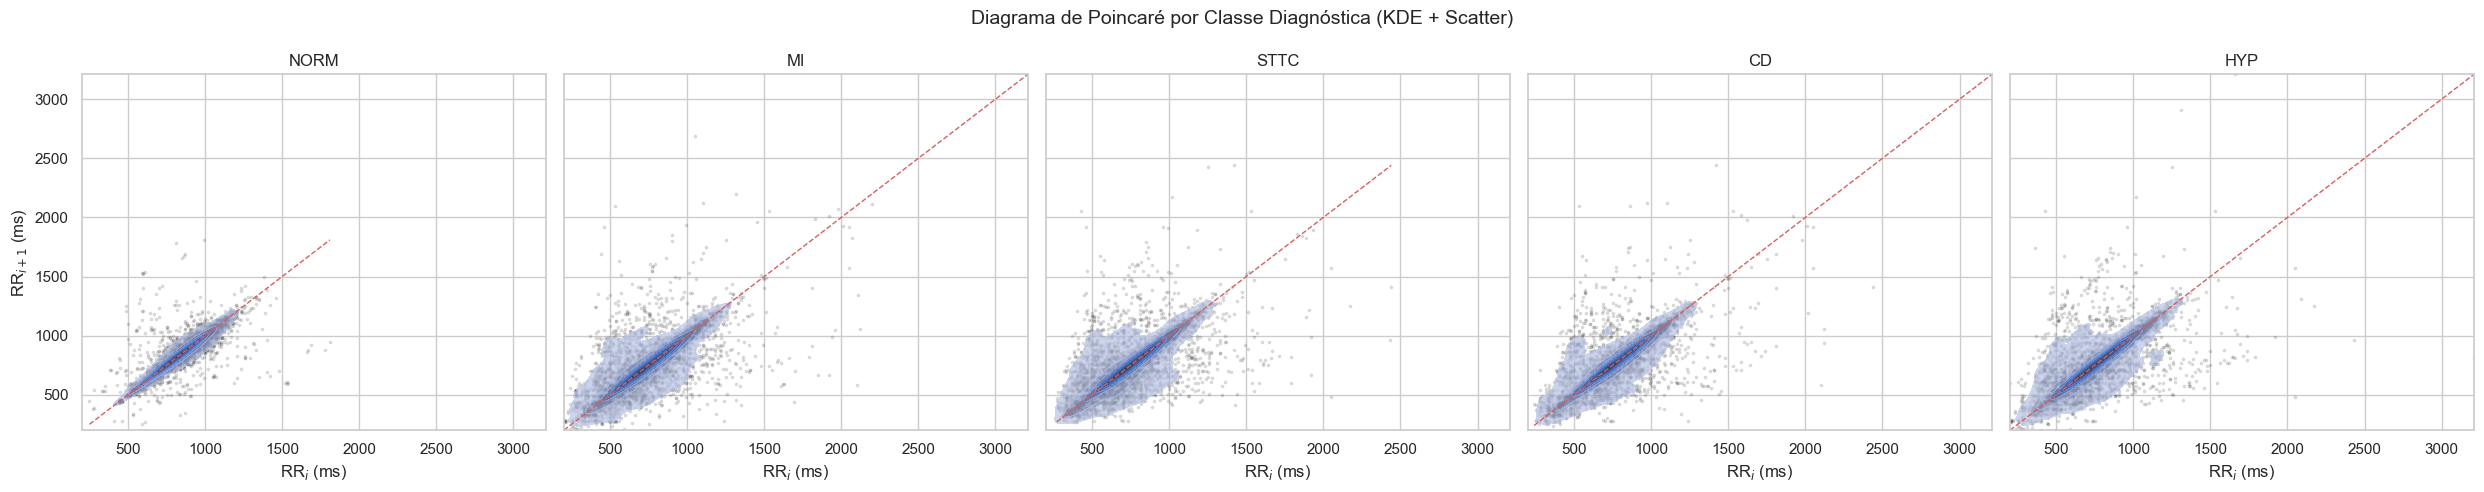

In [14]:
# 6.3 — Diagrama de Poincaré por Classe

fig, axes = plt.subplots(
    1, len(classes_target),
    figsize=(5 * len(classes_target), 5),
    sharex=True, sharey=True
)

for ax, cls in zip(axes, classes_target):

    # Selecionar registros da classe
    ids_cls = df_reg_ids[
        df_reg_ids['superclasses_clean'].apply(
            lambda x: cls in x if isinstance(x, list) else False
        )
    ].index[:1000]  # limitar para legibilidade

    rr_all_x, rr_all_y = [], []

    # Coletar pares (RR_i, RR_i+1)
    for eid in ids_cls:
        rr_s = np.array(rr_groups.get(eid, []), dtype=np.float64)
        rr_s = rr_s[~np.isnan(rr_s)]

        if len(rr_s) >= 3:
            rr_all_x.append(rr_s[:-1])
            rr_all_y.append(rr_s[1:])

    if len(rr_all_x) == 0:
        continue

    rr_x = np.concatenate(rr_all_x)
    rr_y = np.concatenate(rr_all_y)

    # ── Subsample (evita travar KDE) ───────────────────────────────
    max_pts = 300000
    if len(rr_x) > max_pts:
        idx = np.random.choice(len(rr_x), max_pts, replace=False)
        rr_x = rr_x[idx]
        rr_y = rr_y[idx]

    # ── Scatter base (estrutura fina) ──────────────────────────────
    ax.scatter(rr_x, rr_y, s=3, alpha=0.1, color='black')

    # ── KDE (densidade) ────────────────────────────────────────────
    if len(rr_x) > 200:
        sns.kdeplot(
            x=rr_x,
            y=rr_y,
            fill=True,
            levels=8,
            thresh=0.05,
            alpha=0.7,
            ax=ax
        )

    # ── Linha identidade ───────────────────────────────────────────
    lims = [
        np.min([rr_x.min(), rr_y.min()]),
        np.max([rr_x.max(), rr_y.max()])
    ]

    ax.plot(lims, lims, 'r--', lw=1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)

    # ── Labels ─────────────────────────────────────────────────────
    ax.set_title(cls, fontsize=12)
    ax.set_xlabel('RR$_i$ (ms)')

    if ax == axes[0]:
        ax.set_ylabel('RR$_{i+1}$ (ms)')

# ── Layout final ───────────────────────────────────────────────────
plt.suptitle('Diagrama de Poincaré por Classe Diagnóstica (KDE + Scatter)', fontsize=14)
plt.tight_layout()
plt.savefig(FIGS_DIR / 'nonlinear_poincare_por_classe.png',
            dpi=150, bbox_inches='tight')
plt.show()

**Comentários da subseção 6.3:**

A análise dos Diagramas de Poincaré por classe diagnóstica evidencia diferenças relevantes na dinâmica dos intervalos RR, particularmente na **dispersão em torno da linha de identidade** e na **concentração das regiões de densidade**.

De forma geral, todas as classes apresentam uma forte concentração ao longo da diagonal ($RR_i = RR_{i+1}$), indicando alta correlação entre intervalos consecutivos — comportamento esperado em sinais fisiológicos. No entanto, o **grau de espalhamento lateral (variabilidade de curto prazo)** e a presença de **outliers** diferenciam claramente as classes.

A classe **NORM** apresenta uma nuvem elíptica relativamente bem definida, com dispersão moderada e distribuição bastante concentrada. A maior parte dos pontos se encontra entre aproximadamente 600 ms e 1200 ms, com poucos outliers. Esse padrão é consistente com um ritmo estável, porém com variabilidade fisiológica preservada.

Na classe **MI**, observa-se um aumento significativo da dispersão, especialmente na direção vertical e horizontal, com presença de diversos pontos afastados da região central. Há maior densidade em intervalos mais curtos (≈400–800 ms), mas com cauda longa que se estende para valores elevados de RR. Esse comportamento indica maior irregularidade global, com episódios de variação abrupta entre batimentos consecutivos.

A classe **STTC** apresenta uma estrutura semelhante à NORM, porém com leve aumento da dispersão lateral. A nuvem ainda mantém formato elíptico bem organizado, mas com maior espalhamento em torno da diagonal, sugerindo aumento sutil da variabilidade de curto prazo. Ainda assim, não há grande quantidade de outliers extremos.

Na classe **CD**, a nuvem é visivelmente mais espalhada, com maior quantidade de pontos fora da região de maior densidade. Observa-se uma distribuição mais heterogênea, com presença de intervalos tanto curtos quanto longos, indicando irregularidade na condução elétrica. A dispersão não é apenas lateral, mas também ao longo da diagonal, sugerindo variabilidade global aumentada.

A classe **HYP** apresenta uma distribuição semelhante à NORM em termos de formato, porém levemente deslocada para intervalos menores e com maior densidade na faixa de aproximadamente 500–900 ms. A dispersão é moderada, mas inferior à observada em MI e CD. Há também presença de alguns outliers, embora menos pronunciados do que nas classes mais patológicas.

De forma consolidada, os principais padrões observados são:

* **NORM e STTC**: nuvens mais compactas e organizadas, com variabilidade controlada
* **MI e CD**: maior dispersão e presença de outliers, indicando irregularidade do ritmo
* **HYP**: comportamento intermediário, com leve deslocamento para menores intervalos RR

Além disso, a visualização com KDE evidencia que:

* Classes normais tendem a apresentar **regiões de alta densidade bem concentradas**
* Classes patológicas exibem **densidade mais difusa**, indicando múltiplos regimes de operação do ritmo cardíaco

Esses resultados reforçam que o Diagrama de Poincaré captura diferenças relevantes na **estrutura dinâmica dos intervalos RR**, sendo particularmente útil para identificar aumento de variabilidade e irregularidade que não são facilmente observáveis por métricas lineares isoladas.

---

## Seção 7 — Consolidação e Geração do Dataset Final (features_raw)

### 7.1 Unificação de todos os domínios

Reunimos aqui todos os DataFrames gerados nas seções anteriores em um único DataFrame indexado por `ecg_id`. O formato de saída é **Parquet**, preferível ao CSV neste caso por:

- Armazenamento mais eficiente para DataFrames com muitas colunas (> 200) e tipos mistos.
- Preservação dos tipos de dados (`float32`/`float64`) sem arredondamento por representação textual.
- Leitura seletiva de colunas sem carregar o arquivo completo em memória — útil para as etapas de Engenharia de Features e Seleção de Atributos.

Uma cópia em CSV é também salva para inspeção rápida e compatibilidade com ferramentas externas.

In [15]:
# Unificação: join lateral de todos os sub-DataFrames pelo índice ecg_id
# O DataFrame base é df_reg_ids (metadados), ao qual agregamos as features
df_features_raw = df_reg_ids.join(
    [df_time, df_freq, df_beat_final, df_wavelet, df_nonlinear],
    how='left'
)

n_meta  = len(df_reg_ids.columns)
n_feats = len(df_features_raw.columns) - n_meta

print("═" * 55)
print("  SÍNTESE DA EXTRAÇÃO DE ATRIBUTOS — ENTREGÁVEL 6")
print("═" * 55)
display(Markdown(f"""
| Grupo de Features | Nº de Atributos |
|---|---|
| Domínio do Tempo (12 deriv.) | {len(df_time.columns)} |
| Domínio da Frequência (12 deriv.) | {len(df_freq.columns)} |
| Morfologia + HRV (batimento → registro) | {len(df_beat_final.columns)} |
| Wavelet DWT (db4, 4 níveis, DII) | {len(df_wavelet.columns)} |
| Dinâmica Não-Linear (DII + série RR) | {len(df_nonlinear.columns)} |
| **TOTAL DE ATRIBUTOS** | **{n_feats}** |
| Registros no dataset | {len(df_features_raw)} |
"""))

# ── Salvamento ────────────────────────────────────────────────────────────────
path_parquet = OUT_DIR / 'features_raw.parquet'
path_csv     = OUT_DIR / 'features_raw_sample.csv'

df_features_raw.to_parquet(str(path_parquet), index=True)
df_features_raw.to_csv(str(path_csv),     index=True)

print(f"\nArtefatos gerados:")
print(f"  Parquet : {path_parquet.resolve()}")
print(f"  CSV     : {path_csv.resolve()}")

═══════════════════════════════════════════════════════
  SÍNTESE DA EXTRAÇÃO DE ATRIBUTOS — ENTREGÁVEL 6
═══════════════════════════════════════════════════════



| Grupo de Features | Nº de Atributos |
|---|---|
| Domínio do Tempo (12 deriv.) | 84 |
| Domínio da Frequência (12 deriv.) | 84 |
| Morfologia + HRV (batimento → registro) | 25 |
| Wavelet DWT (db4, 4 níveis, DII) | 32 |
| Dinâmica Não-Linear (DII + série RR) | 6 |
| **TOTAL DE ATRIBUTOS** | **231** |
| Registros no dataset | 17744 |



Artefatos gerados:
  Parquet : C:\Users\User\Desktop\repo-lessa\entregaveis\entregavel-6\outputs\features_raw.parquet
  CSV     : C:\Users\User\Desktop\repo-lessa\entregaveis\entregavel-6\outputs\features_raw_sample.csv


---


## Seção 8 — Verificação de Sanidade do Dataset (Sanity Check)

Antes de encerrar este entregável, realizamos uma série de verificações quantitativas e qualitativas para garantir que o dataset gerado está íntegro e pronto para ser utilizado na etapa de Engenharia de Features.


### 8.1 Completude e Valores Ausentes

In [16]:
# ── Completude geral ─────────────────────────────────────────────────────────
n_total  = df_features_raw.shape[0] * df_features_raw.shape[1]
n_nulls  = df_features_raw.isnull().sum().sum()
pct_null = 100 * n_nulls / n_total

print(f"Dimensão total do dataset  : {df_features_raw.shape}")
print(f"Valores ausentes totais    : {int(n_nulls)} ({pct_null:.2f}% das células)")

# Identificar colunas com maior proporção de NaNs
null_por_col = df_features_raw.isnull().mean().sort_values(ascending=False)
cols_com_null = null_por_col[null_por_col > 0]

if len(cols_com_null) > 0:
    print(f"\nColunas com valores ausentes ({len(cols_com_null)} no total):")
    display(cols_com_null.reset_index().rename(
        columns={'index': 'Feature', 0: 'Proporção de NaN'}
    ).head(20))
    print("\nAviso: valores ausentes concentram-se nas features não-lineares da série RR,")
    print("esperados para registros com menos de 8 batimentos detectados.")
    print("Serão tratados por imputação ou exclusão no Entregável 7.")
else:
    print("\nNenhum valor ausente detectado — dataset completo.")

Dimensão total do dataset  : (17744, 238)
Valores ausentes totais    : 19222 (0.46% das células)

Colunas com valores ausentes (12 no total):


,Feature,Proporção de NaN
0,nonlin_sampen_rr,1.000000
1,nonlin_sd1_sd2_ratio,0.028235
2,nonlin_sd2,0.028179
3,nonlin_sd1,0.026037
4,morph_st_amp_V5_std,0.000225
5,morph_st_amp_II_std,0.000169
6,morph_st_amp_V5_median,0.000113
7,morph_st_amp_II_median,0.000113
8,hrv_rmssd,0.000056
9,hrv_sdRR,0.000056



Aviso: valores ausentes concentram-se nas features não-lineares da série RR,
esperados para registros com menos de 8 batimentos detectados.
Serão tratados por imputação ou exclusão no Entregável 7.


In [17]:
# ── Verificação de ranges esperados ──────────────────────────────────────────
print("Verificação de ranges para features-chave:\n")

checks = {
    'time_rms_II'      : (0.0, 5.0),    # RMS em mV (ECG típico < 3 mV)
    'freq_qrs_ratio_II': (0.0, 1.0),    # Razão entre 0 e 1
    'hrv_meanRR'       : (300, 2000),   # RR médio em ms (FC 30-200 bpm)
    'hrv_rmssd'        : (0.0, 500),    # RMSSD em ms
    'nonlin_higuchi_fd': (1.0, 2.0),    # Dimensão fractal (definição matemática)
    'nonlin_dfa_alpha' : (0.0, 2.5),    # Expoente DFA (limites práticos)
}

status_global = True
for feat, (vmin, vmax) in checks.items():
    if feat not in df_features_raw.columns:
        print(f"  [SKIP]  {feat} — coluna não encontrada")
        continue

    col      = df_features_raw[feat].dropna()
    fora     = ((col < vmin) | (col > vmax)).sum()
    pct_fora = 100 * fora / len(col) if len(col) > 0 else 0
    status   = "✓ OK" if pct_fora < 2 else "⚠ REVISAR"
    if pct_fora >= 2:
        status_global = False

    print(f"  [{status}]  {feat:35s}  range=({col.min():.3f}, {col.max():.3f})  "
          f"fora do esperado: {fora} ({pct_fora:.1f}%)")

print()
if status_global:
    print("Todas as verificações de range passaram dentro da tolerância de 2%.")
else:
    print("Atenção: algumas features apresentaram valores fora do range esperado.")
    print("Verificar se são outliers residuais (a serem tratados no Entregável 7).")

Verificação de ranges para features-chave:

  [✓ OK]  time_rms_II                          range=(0.024, 0.395)  fora do esperado: 0 (0.0%)
  [✓ OK]  freq_qrs_ratio_II                    range=(0.028, 0.927)  fora do esperado: 0 (0.0%)
  [✓ OK]  hrv_meanRR                           range=(300.968, 7940.000)  fora do esperado: 10 (0.1%)
  [✓ OK]  hrv_rmssd                            range=(0.000, 3188.518)  fora do esperado: 169 (1.0%)
  [✓ OK]  nonlin_higuchi_fd                    range=(1.058, 1.896)  fora do esperado: 0 (0.0%)
  [✓ OK]  nonlin_dfa_alpha                     range=(0.430, 1.547)  fora do esperado: 0 (0.0%)

Todas as verificações de range passaram dentro da tolerância de 2%.


### 8.2 Tabela de Features Extraídas (Inventário Completo)

A célula abaixo gera e salva a tabela de inventário de features — lista completa com nome, domínio, derivação e interpretação clínica básica.

In [18]:
def build_feature_catalog(df_feats, df_meta_cols):
    """
    Gera um DataFrame com inventário das features extraídas,
    classificando-as por domínio e fornecendo interpretação básica.
    """
    feat_cols = [c for c in df_feats.columns if c not in df_meta_cols]

    domain_map = {
        'time_'    : 'Tempo',
        'freq_'    : 'Frequência',
        'hrv_'     : 'HRV (Tempo)',
        'morph_'   : 'Morfologia',
        'wavelet_' : 'Tempo-Frequência (Wavelet)',
        'nonlin_'  : 'Não-Linear',
    }

    rows = []
    for col in feat_cols:
        domain = 'Outro'
        for prefix, d in domain_map.items():
            if col.startswith(prefix):
                domain = d
                break

        nan_pct = float(df_feats[col].isnull().mean() * 100)
        rows.append({
            'Feature'         : col,
            'Domínio'         : domain,
            'Média'           : round(float(df_feats[col].mean()), 4),
            'Desvio Padrão'   : round(float(df_feats[col].std()),  4),
            '% NaN'           : round(nan_pct, 2),
        })

    return pd.DataFrame(rows)


meta_cols = list(df_reg_ids.columns)
df_catalog = build_feature_catalog(df_features_raw, meta_cols)

# Salvamento do catálogo
catalog_path = OUT_DIR / 'feature_catalog.csv'
df_catalog.to_csv(str(catalog_path), index=False)

print(f"Catálogo salvo em: {catalog_path.resolve()}")
print(f"Total de features catalogadas: {len(df_catalog)}")
print()

# Resumo por domínio
display(df_catalog.groupby('Domínio').size()
        .reset_index(name='Nº de Features')
        .sort_values('Nº de Features', ascending=False))

Catálogo salvo em: C:\Users\User\Desktop\repo-lessa\entregaveis\entregavel-6\outputs\feature_catalog.csv
Total de features catalogadas: 231



,Domínio,Nº de Features
0,Frequência,84
4,Tempo,84
5,Tempo-Frequência (Wavelet),32
2,Morfologia,20
3,Não-Linear,6
1,HRV (Tempo),5


### **8.3 Visualização Final: Mapa de Calor de Correlações entre Features-Chave**

Nesta etapa, foram construídos dois mapas de calor baseados na correlação de Pearson entre as features extraídas: um **heatmap completo**, considerando todas as variáveis numéricas do dataset, e um **heatmap reduzido**, contendo apenas as features envolvidas em correlações elevadas (|r| > 0,90) entre domínios distintos.

O objetivo dessas visualizações é investigar a estrutura de dependência entre as features e identificar possíveis padrões de redundância informacional entre diferentes representações do sinal. Correlações muito altas entre domínios distintos indicam sobreposição de informação e serão formalmente tratadas na etapa de **Seleção de Atributos (Entregável 9)**, com foco na redução de multicolinearidade e na preservação da representatividade do conjunto de features.


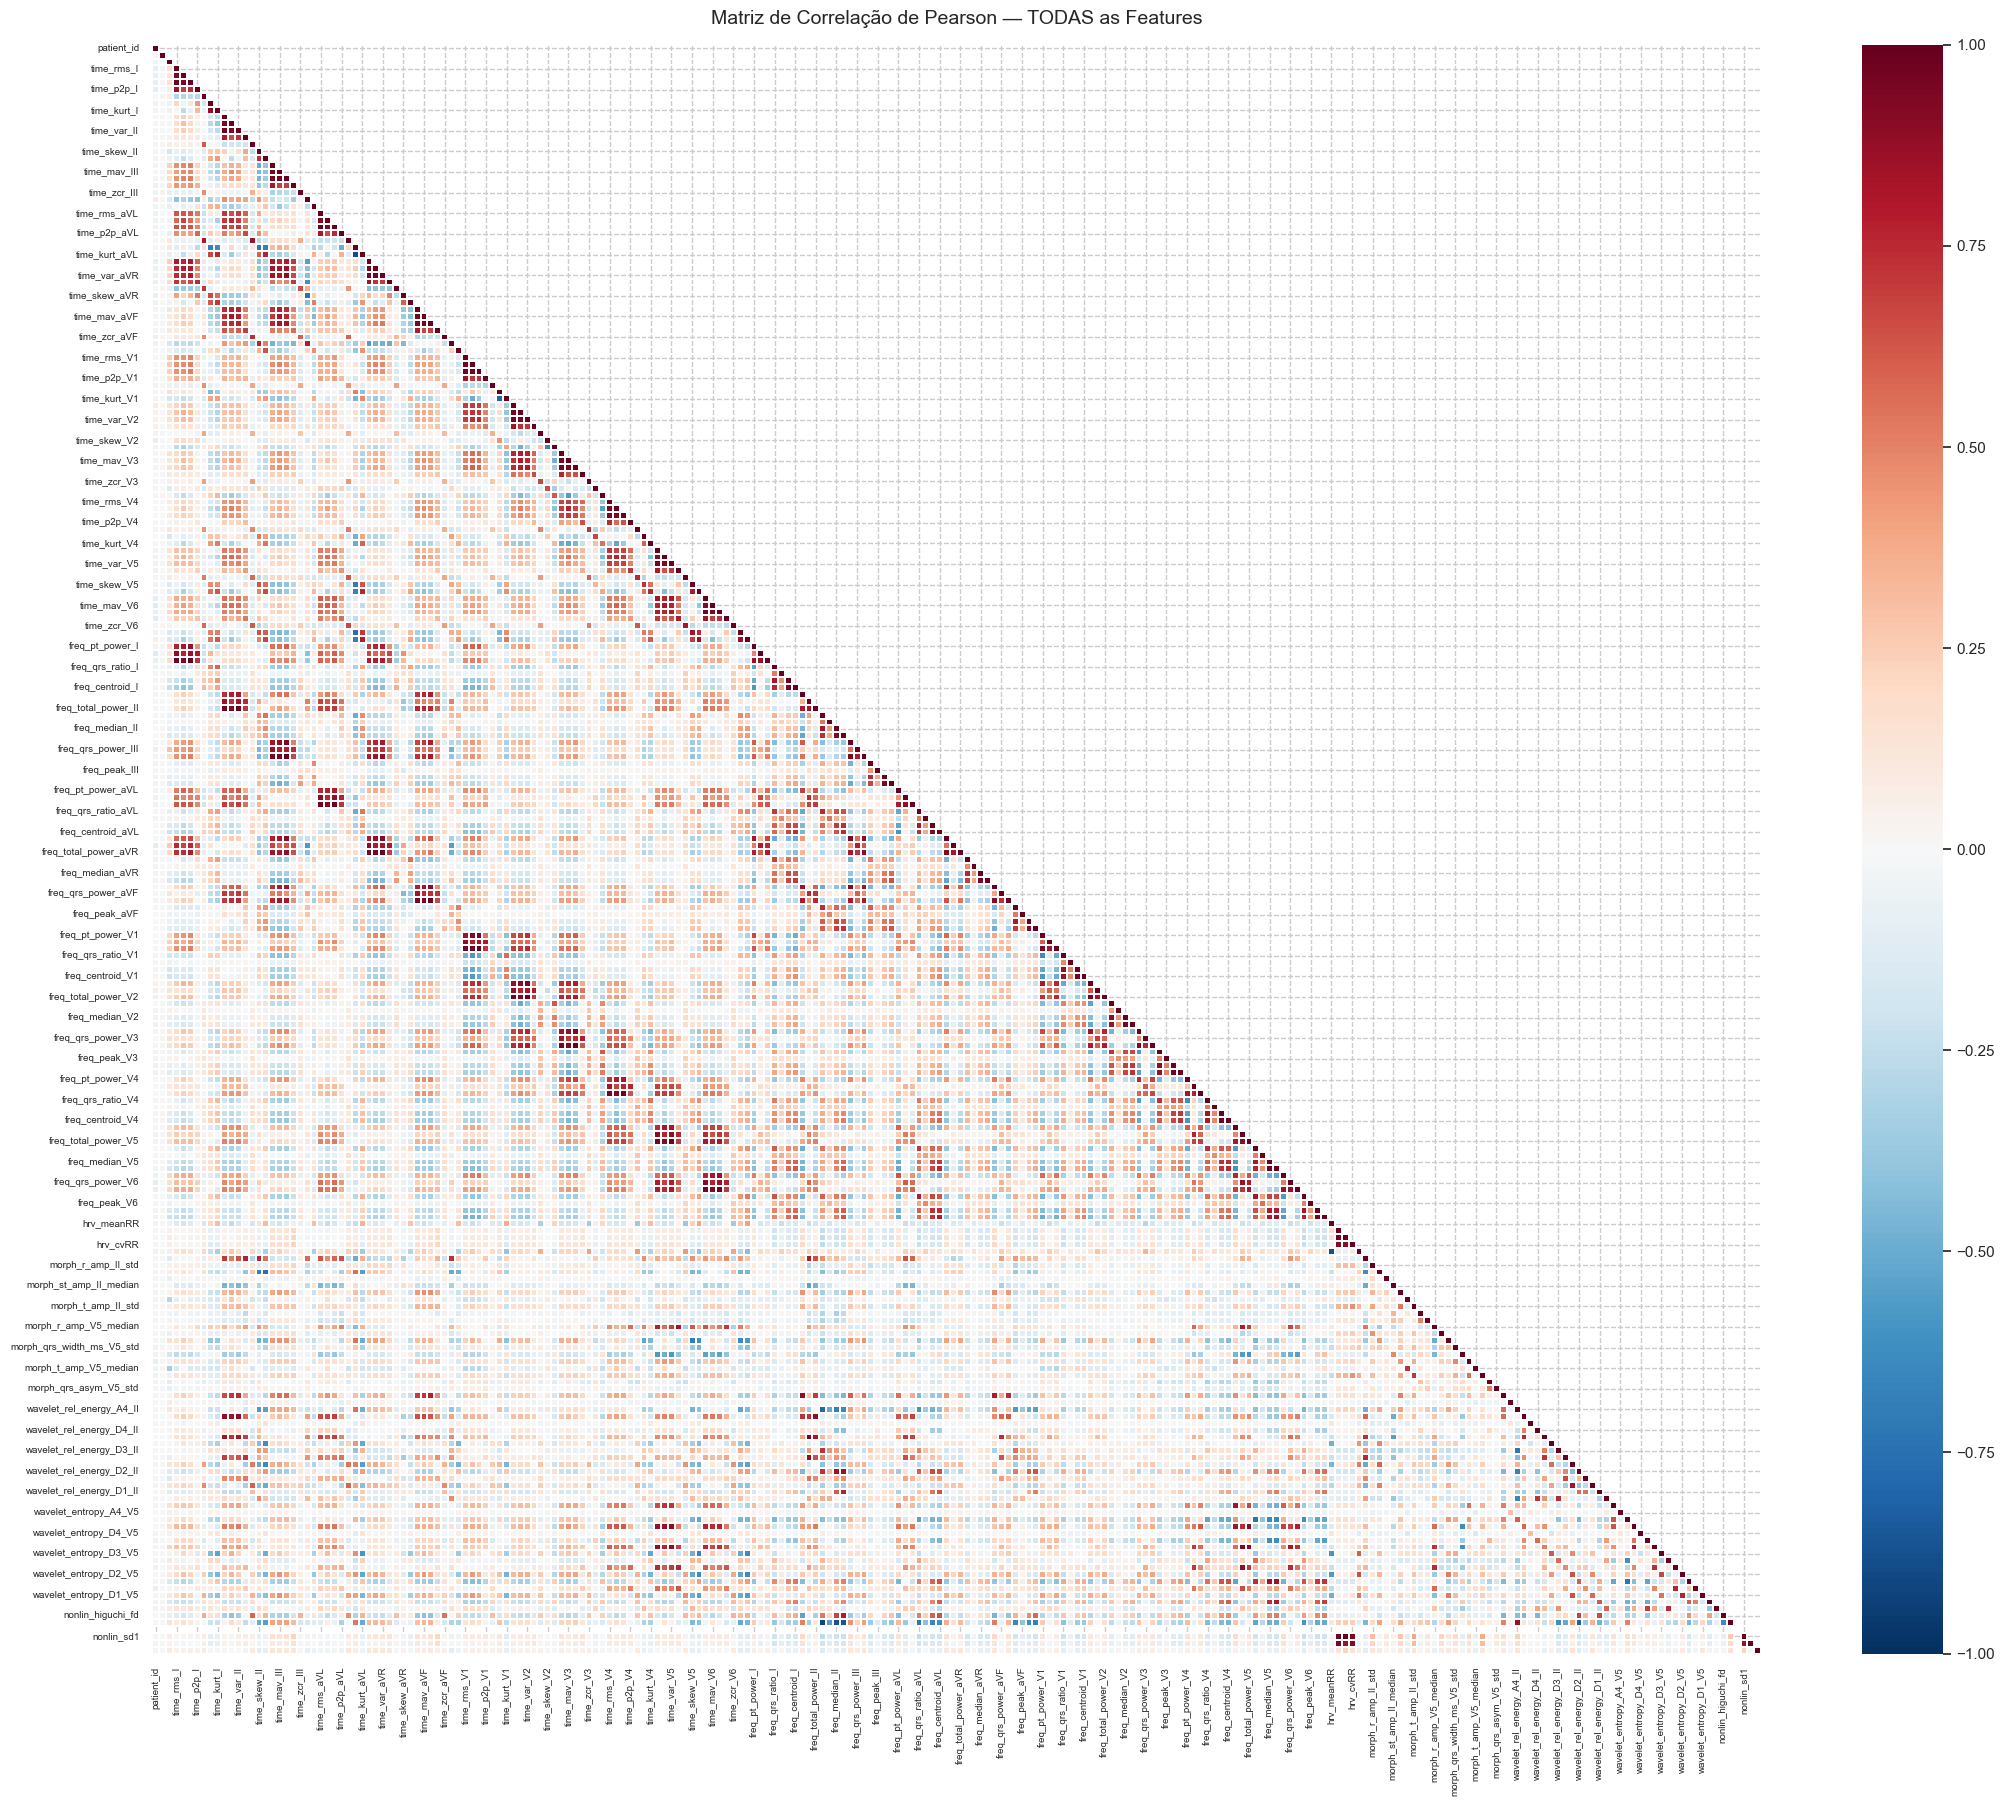

In [19]:
# Heatmap de correlação - TODAS as features

# Seleciona apenas colunas numéricas (boa prática para evitar erro)
df_numeric = df_features_raw.select_dtypes(include=[np.number])

# Matriz de correlação de Pearson
df_corr = df_numeric.corr(method='pearson')

fig, ax = plt.subplots(figsize=(22, 18))

# Máscara para mostrar apenas metade superior (evita redundância visual)
mask = np.triu(np.ones_like(df_corr, dtype=bool), k=1)

sns.heatmap(
    df_corr,
    mask=mask,
    cmap='RdBu_r',
    vmin=-1, vmax=1,
    linewidths=0.2,
    square=True,
    ax=ax
)

ax.set_title(
    'Matriz de Correlação de Pearson — TODAS as Features',
    fontsize=14,
    pad=15
)

plt.xticks(rotation=90, fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()

plt.savefig(
    FIGS_DIR / 'heatmap_correlacao_todas_features.png',
    dpi=200,
    bbox_inches='tight'
)

plt.show()

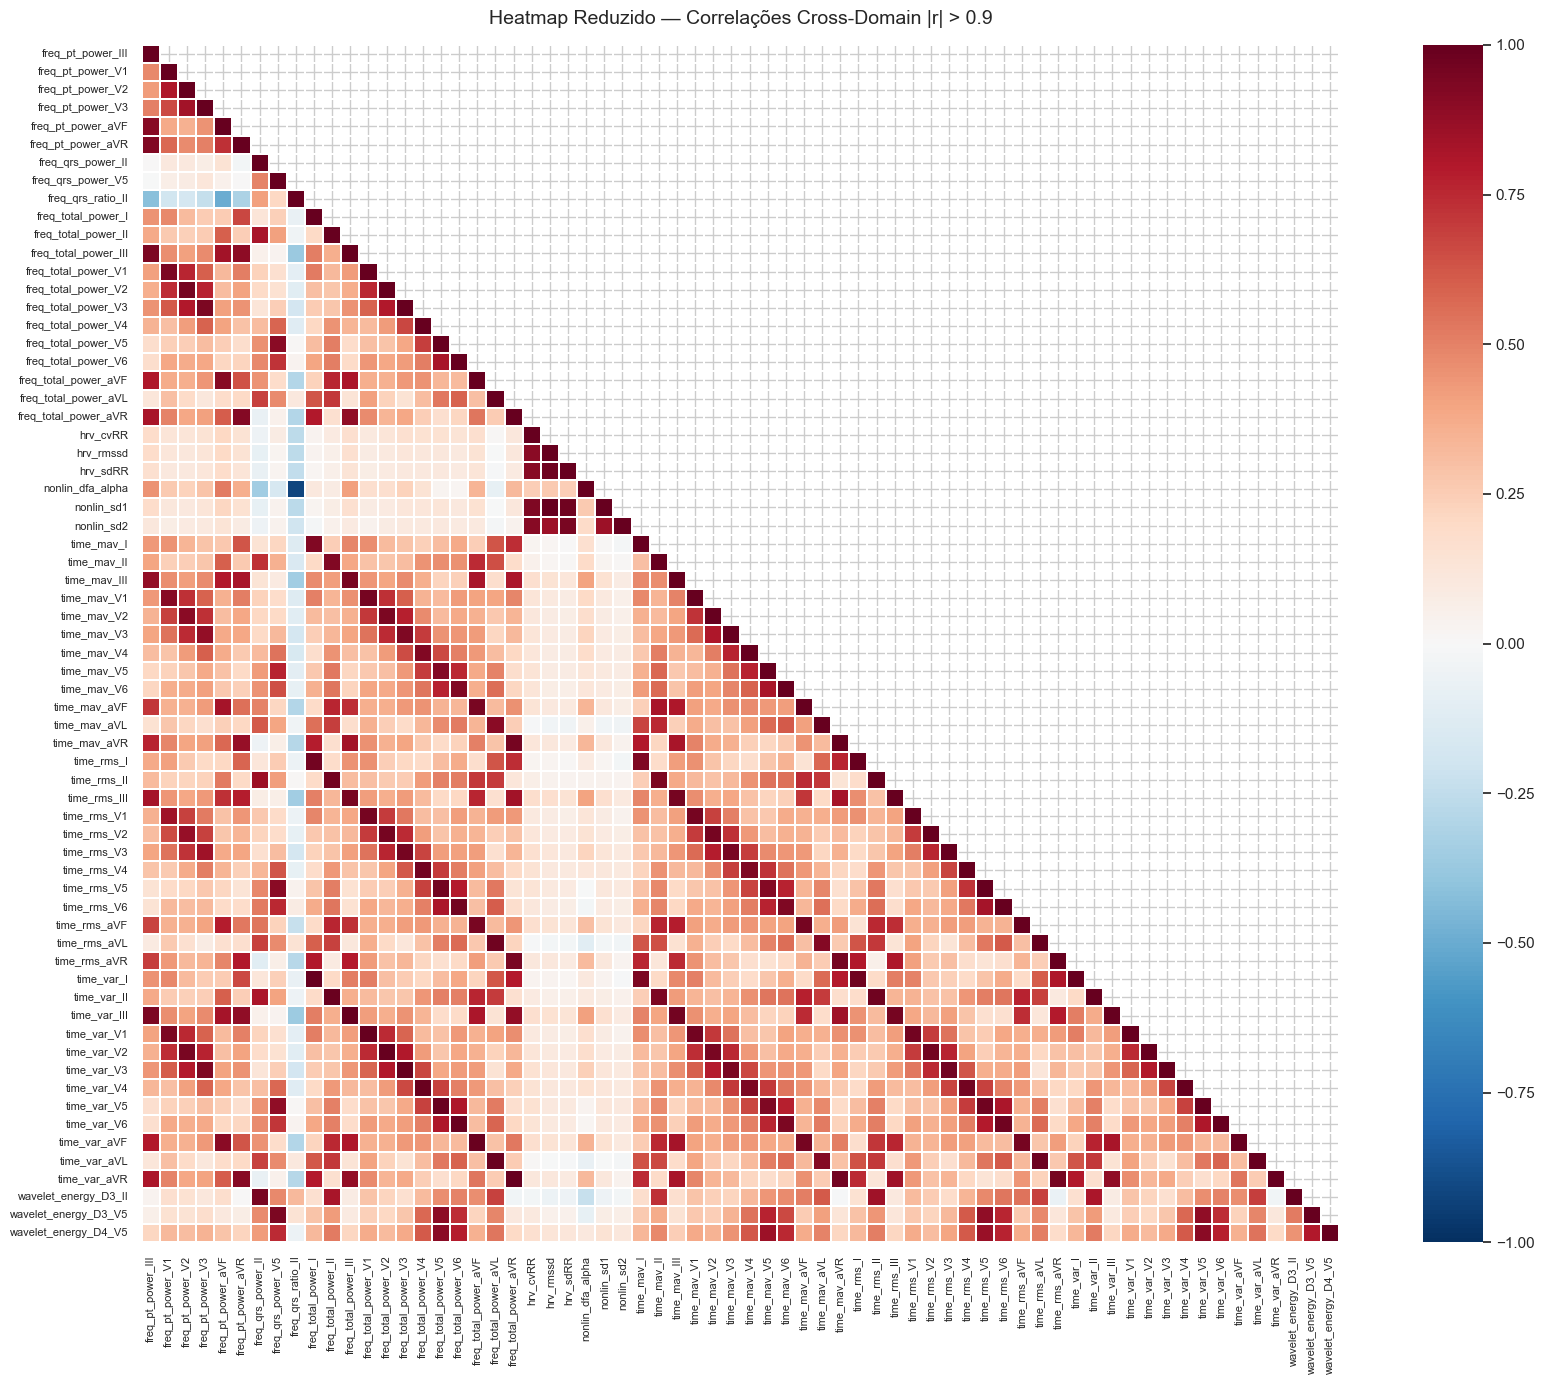

Total de features no heatmap reduzido: 66


In [22]:
# HEATMAP REDUZIDO: features com |r| > 0.9 cross-domain

# MATRIZ DE CORRELAÇÃO COMPLETA
df_numeric = df_features_raw.select_dtypes(include=[np.number])
corr = df_numeric.corr()

# MAPA DE DOMÍNIOS
feature_to_domain = dict(zip(df_catalog['Feature'], df_catalog['Domínio']))

# EXTRAÇÃO DE PARES
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .reset_index()
)

corr_pairs.columns = ['feature_1', 'feature_2', 'correlation']

# FILTRO: |r| > 0.9 + domínios diferentes
features_reduzidas = set()

for _, row in corr_pairs.iterrows():
    f1, f2, r = row['feature_1'], row['feature_2'], row['correlation']
    
    if abs(r) > 0.9:
        d1 = feature_to_domain.get(f1, 'Outro')
        d2 = feature_to_domain.get(f2, 'Outro')
        
        if d1 != d2:
            features_reduzidas.add(f1)
            features_reduzidas.add(f2)

features_reduzidas = sorted(list(features_reduzidas))

# SUBSET REDUZIDO
df_reduced = df_numeric[features_reduzidas]
corr_reduced = df_reduced.corr()

# ordenação para melhor visualização
corr_reduced = corr_reduced.loc[features_reduzidas, features_reduzidas]

# HEATMAP REDUZIDO
fig, ax = plt.subplots(figsize=(18, 14))

mask = np.triu(np.ones_like(corr_reduced, dtype=bool), k=1)

sns.heatmap(
    corr_reduced,
    mask=mask,
    cmap='RdBu_r',
    vmin=-1, vmax=1,
    annot=False,
    linewidths=0.3,
    square=True,
    ax=ax
)

ax.set_title(
    'Heatmap Reduzido — Correlações Cross-Domain |r| > 0.9',
    fontsize=14,
    pad=15
)

# EIXOS COM NOMES COMPLETOS
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

plt.tight_layout()
plt.savefig(
    FIGS_DIR / 'heatmap_correlacao_0.90+_features_dom_distintos.png',
    dpi=200,
    bbox_inches='tight'
)

plt.show()

# DEBUG
print(f"Total de features no heatmap reduzido: {len(features_reduzidas)}")

**Comentários da subseção 8.3:**

A análise do heatmap reduzido de correlação entre features selecionadas evidencia um padrão claro de **forte redundância interdomínio**, com múltiplas relações lineares de alta magnitude (|r| > 0.9) entre variáveis derivadas de representações distintas do mesmo sinal fisiológico.

De forma geral, observa-se que os domínios **Tempo (time_var, time_rms, time_mav)** e **Frequência (freq_total_power, freq_pt_power)** apresentam correlações extremamente elevadas, frequentemente superiores a 0.95. Esse comportamento indica que diferentes estatísticas temporais do sinal estão capturando essencialmente a mesma variação energética já representada no domínio espectral. Assim, há uma forte sobreposição informacional entre essas duas famílias de features.

Em particular, as features do tipo **variância e RMS por derivação (time_var_*, time_rms_*)** apresentam correlação quase determinística com **potência total no domínio da frequência (freq_total_power_*)**, sugerindo que ambas estão diretamente associadas à energia global do sinal. Essa redundância é consistente com propriedades conhecidas de sinais biomédicos, nos quais energia temporal e espectral tendem a ser altamente dependentes.

O domínio **HRV (hrv_rmssd, hrv_sdRR, hrv_cvRR)** também apresenta forte colinearidade interna e interconexão com o domínio **não-linear (nonlin_sd1, nonlin_sd2)**. Em alguns casos, observa-se correlação praticamente perfeita (≈1.0), o que indica que essas métricas estão descrevendo variações muito semelhantes da dinâmica dos intervalos RR, apenas sob diferentes formulações matemáticas.

Adicionalmente, observa-se que o domínio **Wavelet (wavelet_energy_D3, D4)** apresenta correlações elevadas com features espectrais clássicas (freq_qrs_power), especialmente em derivações como V5 e II. Isso sugere que a decomposição tempo-frequência via wavelets está capturando componentes energéticos já fortemente representados no espectro de potência convencional.

Um ponto relevante é a presença de correlações negativas isoladas, como entre **freq_qrs_ratio_II e nonlin_dfa_alpha (-0.914)**. Esse tipo de relação indica um possível comportamento complementar entre complexidade não-linear do sinal e dominância espectral, sugerindo que enquanto uma métrica aumenta, a outra tende a reduzir, refletindo possíveis mudanças na regularidade do ritmo cardíaco.

De forma consolidada, o heatmap evidencia a formação de **blocos altamente correlacionados entre domínios**, especialmente:

* **Bloco Tempo ↔ Frequência**: redundância estrutural dominante (correlações 0.95–0.99)
* **Bloco HRV ↔ Não-linear**: forte sobreposição fisiológica (até correlação ~1.0)
* **Bloco Wavelet ↔ Frequência**: redundância parcial de representação espectral

Esses padrões indicam que o conjunto de features não possui independência estatística significativa entre diversas representações, mas sim uma organização em **grupos altamente colineares que descrevem os mesmos fenômenos fisiológicos sob diferentes transformações matemáticas**.

Em termos de modelagem, esse comportamento sugere que o espaço de features pode ser reduzido substancialmente sem perda significativa de informação, desde que seja preservada ao menos uma variável representativa por cluster de alta correlação. Isso reforça a necessidade de uma etapa formal de **seleção de atributos baseada em redundância interdomínio** (entregável 9), evitando multicolinearidade excessiva e melhorando a interpretabilidade do modelo final.

---

## Seção 9 — Síntese e Conexão com o Entregável 7

### 9.1 O que foi feito neste entregável

Neste entregável, realizamos a transformação completa dos sinais de ECG brutos em um **dataset estruturado de features numéricas**, cobrindo quatro domínios complementares de análise:

- **Domínio do Tempo:** estatísticas descritivas de amplitude sobre as 12 derivações, capturando distribuição de energia e forma da distribuição de amplitudes.
- **Domínio da Frequência:** análise espectral via método de Welch, com integração de potência em bandas fisiológicas (PT, QRS) e descritores de forma da PSD.
- **Morfologia e HRV:** extração por batimento individual (via segmentação do Entregável 5) e agregação para o nível do registro, capturando amplitudes de ondas, durações de segmentos e variabilidade do ritmo cardíaco.
- **Domínio Tempo-Frequência:** decomposição Wavelet com família db4 em 4 níveis, extraindo energia e entropia por sub-banda.
- **Dinâmica Não-Linear:** dimensão fractal de Higuchi, expoente DFA e métricas do Diagrama de Poincaré, capturando a complexidade intrínseca do sinal e das séries RR.

### 9.2 Limitações e decisões metodológicas relevantes

- **Restrição de domínios complexos às derivações DII e V5:** para Wavelet, DFA, Higuchi e SampEn, o cálculo foi restrito às derivações DII e V5 por custo computacional. Trabalhos futuros podem estender esses cálculos para mais derivações, potencialmente aumentando a discriminabilidade entre classes.

- **Valores ausentes nas features não-lineares da série RR:** registros com menos de 8 batimentos detectados (seja por sinal curto, arritmia severa ou falhas no detector Pan-Tompkins) resultam em NaN nessas features. Essa limitação é esperada e documentada no catálogo de features.

- **Sem normalização nesta etapa:** as features estão em suas escalas originais (mV, ms, Hz, adimensional). A normalização robusta será realizada no **Entregável 7 (Engenharia de Features)**, que também explorará features de segunda ordem (razões entre bandas, diferenças temporais) e tratará os valores ausentes.

### 9.3 Próximos passos — Entregável 7

O dataset `features_raw.parquet` gerado aqui constitui a entrada do **Entregável 7 (Engenharia de Features)**, que realizará:

1. **Normalização robusta** (por escalonamento baseado em mediana/IQR do conjunto de treino), evitando *data leakage* nos conjuntos de validação e teste.
2. **Criação de features derivadas** — razões entre bandas espectrais (ex: QRS/PT), deltas morfológicos (variação de amplitude R entre derivações), e combinações de métricas de HRV.
3. **Imputação dos valores ausentes** nas features não-lineares — por mediana do conjunto de treino ou por regressão baseada em features temporais correlacionadas.
4. **Análise de redundância** entre features dos diferentes domínios — preparando o dataset para a Seleção de Atributos do Entregável 9.

In [21]:
# Verificação final consolidada
print("═" * 55)
print("   VERIFICAÇÃO FINAL — ENTREGÁVEL 6")
print("═" * 55)
print(f"  Dimensão do dataset final : {df_features_raw.shape}")
print(f"  Total de features         : {n_feats}")
print(f"  Valores ausentes totais   : {int(df_features_raw.isnull().sum().sum())}")
print(f"  Arquivos gerados:")
print(f"    - features_raw.parquet")
print(f"    - features_raw_sample.csv")
print(f"    - feature_catalog.csv")
print(f"    - {len(list(FIGS_DIR.glob('*.png')))} figuras em {FIGS_DIR}")
print()
print("  Dataset pronto para o Entregável 7 — Engenharia de Features.")
print("═" * 55)

═══════════════════════════════════════════════════════
   VERIFICAÇÃO FINAL — ENTREGÁVEL 6
═══════════════════════════════════════════════════════
  Dimensão do dataset final : (17744, 238)
  Total de features         : 231
  Valores ausentes totais   : 19222
  Arquivos gerados:
    - features_raw.parquet
    - features_raw_sample.csv
    - feature_catalog.csv
    - 8 figuras em ..\figuras

  Dataset pronto para o Entregável 7 — Engenharia de Features.
═══════════════════════════════════════════════════════
